# Google Sheets for OWLR Data

 https://docs.google.com/spreadsheets/d/1FgQRhw9HWl-7XXXsmWhnBUNeneZqLjEzmYZBD_2KLuo/edit?gid=0#gid=0

In [1]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

# File Paths and Processing

The following code begins with defining file paths and ensures it is using the correct columns for rainfall data. Data is loaded and processed to ensure rainfall is in the same units and there is correct summation of rainfall events. 



In [2]:
# STEP 1: Define file paths and helper functions
# Earliest data from OWLR_CMS is Dec 19, 2025, therefore all graphs begin at this time stamp.
file_1 = "Data/precip_CORMP_03172026.csv"   # needs hourly sum
file_2 = "Data/precip_Davis_03172026.csv"   # needs hourly sum
file_3 = "Data/OWLR_CMS_03172026.csv"   # already hourly

import io # for in-memory file operations
import re # for regular expressions

# detects header row by looking for keywords in the first max_lines (200) lines
# looking for for keywords like 'date' or 'time', combined with a comma (typical CSV header indicator).
def detect_header_row(path, max_lines=200):
    with open(path, 'r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh):
            if i >= max_lines:
                break
            low = line.lower()
            # looking for header lines usually contain 'date' or 'time' and a comma
            if (('date' in low or 'time' in low) and ',' in line) or ('date &' in low):
                return i
    return 0


# Load and process rainfall_0 CSV file with "smart column detection". Returns data from datetime and rainfall 
# Converts units if needed, and resamples to hourly aggregates.
def load_and_process(filepath, assume_inches=False, already_hourly=False, parse_embedded_string=False):
    path = os.path.join(filepath)
    
    # Special handling for rainfall_0000 format: use header=None to preserve comma-separated string values
    if parse_embedded_string:
        df = pd.read_csv(path, header=None, engine='python')
        # Assign column names for embedded string format
        df.columns = ['Device_ID', 'Datetime', 'Sensor', 'Data']
        dtcol = 'Datetime'
        rcol = 'Data'
    else:
        header_row = detect_header_row(path, max_lines=200)
        try:
            # set header to detected row; also skip percent-comment lines
            df = pd.read_csv(path, header=header_row, comment='%', engine='python')
        except Exception as e:
            print(f"read_csv failed for {path}: {e}")
            df = pd.read_csv(path, engine='python', sep=None, on_bad_lines='warn')

        # ensure column names are strings
        df.columns = [str(c) for c in df.columns]

        # find datetime column by keywords or by attempting to parse columns
        datetime_cols = [c for c in df.columns if any(k in c.lower() for k in ('date','time','datetime','timestamp'))]
        dtcol = None
        if datetime_cols: # found by keyword
            dtcol = datetime_cols[0]
        else:
            for c in df.columns:
                try:
                    parsed = pd.to_datetime(df[c], errors='coerce') # try to parse as datetime
                    if parsed.notna().sum() > 0: # at least some valid datetimes
                        dtcol = c
                        break
                except Exception:
                    continue
        if dtcol is None:
            raise ValueError(f"No datetime-like column found in {filepath}")

        # find rainfall column
        rain_cols = [c for c in df.columns if any(k in c.lower() for k in ('rain','precip','mm','inches'))]
        if rain_cols:
            rcol = rain_cols[0]
        else:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            rcol = numeric_cols[0] if numeric_cols else None

        if rcol is None:
            for c in df.columns:
                coerced = pd.to_numeric(df[c], errors='coerce')
                if coerced.notna().sum() > 0:
                    rcol = c
                    df[c] = coerced
                    break
        if rcol is None:
            raise ValueError(f"No rainfall/numeric column found in {filepath}")

    df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce')

    # Special handling for rainfall_0000 format: extract rainfall value from comma-separated string (3rd value)
    if parse_embedded_string:
        def extract_rain_value(val):
            try:
                if pd.isna(val):
                    return np.nan
                val_str = str(val).strip().strip('"')  # remove quotes if present
                parts = [p.strip() for p in val_str.split(',')]
                if len(parts) > 2:
                    return float(parts[2])  # 3rd value (index 2) is rainfall in mm
                else:
                    return np.nan
            except:
                return np.nan
        df['rain_mm'] = df[rcol].apply(extract_rain_value)
        rcol = 'rain_mm'
    else:
        df[rcol] = pd.to_numeric(df[rcol], errors='coerce')
        if assume_inches:
            df[rcol] = df[rcol] * 25.4

    subset_cols = [c for c in ['datetime', rcol] if c in df.columns]
    df = df.dropna(subset=subset_cols)

    if 'datetime' in df.columns:
        df = df.set_index('datetime')
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise KeyError('datetime')

    if already_hourly:
        hourly = df.reset_index().rename(columns={rcol: 'rain_mm'})
        if 'datetime' not in hourly.columns:
            hourly = hourly.rename(columns={hourly.columns[0]: 'datetime'})
    else:
        hourly = df[rcol].resample('h').sum().reset_index().rename(columns={rcol: 'rain_mm'})
    return hourly


# STEP 2: Load and process all three rainfall files

print("Loading and processing rainfall data...")
cormp = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

print(f"  TR-525l: {len(cormp)} hourly records")
print(f"  Davis: {len(davis)} hourly records")
print(f"  OWLR_CMS: {len(rain0)} hourly records")


# STEP 3: Filter to the analysis date range (Dec 19, 2025 - Mar 17, 2026)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-03-17 09:00')

print(f"\nFiltering to period: {start} to {end}")

cormp = cormp[(cormp['datetime'] >= start) & (cormp['datetime'] <= end)].reset_index(drop=True)
davis = davis[(davis['datetime'] >= start) & (davis['datetime'] <= end)].reset_index(drop=True)
rain0 = rain0[(rain0['datetime'] >= start) & (rain0['datetime'] <= end)].reset_index(drop=True)

print(f"  CORMP (filtered): {len(cormp)} records")
print(f"  Davis (filtered): {len(davis)} records")
print(f"  OWLR_CMS (filtered): {len(rain0)} records")

Loading and processing rainfall data...
  TR-525l: 2125 hourly records
  Davis: 2127 hourly records
  OWLR_CMS: 2448 hourly records

Filtering to period: 2025-12-19 09:00:00 to 2026-03-17 09:00:00
  CORMP (filtered): 2113 records
  Davis (filtered): 2113 records
  OWLR_CMS (filtered): 2293 records


# Full Period Scatter Plot

This cell plots a full period scatter plot of all three sensors. 



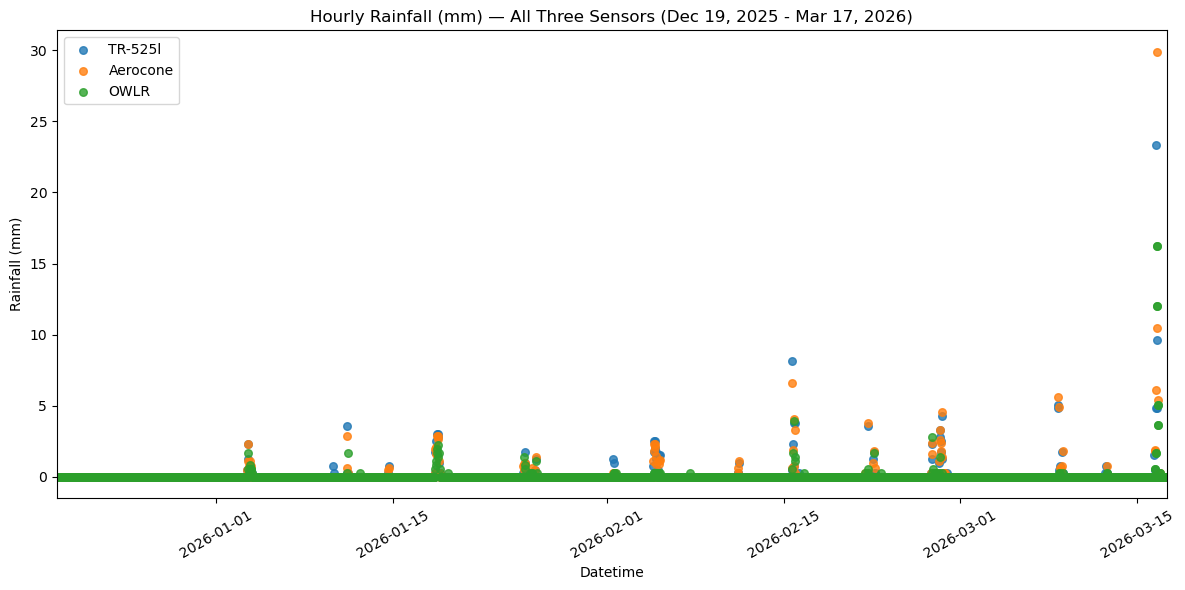

In [3]:

plt.figure(figsize=(12,6))
if not cormp.empty:
    plt.scatter(cormp['datetime'], cormp['rain_mm'], label='TR-525l', s=30, alpha=0.8)
if not davis.empty:
    plt.scatter(davis['datetime'], davis['rain_mm'], label='Aerocone', s=30, alpha=0.8)
if not rain0.empty:
    plt.scatter(rain0['datetime'], rain0['rain_mm'], label='OWLR', s=30, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('Hourly Rainfall (mm) — All Three Sensors (Dec 19, 2025 - Mar 17, 2026)')
plt.legend()
plt.xlim(start, end)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Full Period Comparison

Comparison between TR525l (used with CORMP) vs. Aerocone (used with Davis) and OWLR.



FULL PERIOD ANALYSIS: CORMP vs Davis vs OWLR_CMS
December 19th, 2025 - March 17th, 2026

Data summary:
  CORMP records: 2113
  Davis records: 2113
  OWLR_CMS records: 2293

Merged dataset shape: (2304, 8)

CORP vs Davis:
  Pearson Correlation: 0.6073
  R²: 0.3688
  Slope: 0.7287
  MAPE: 65.26%

CORP vs OWLR_CMS:
  Pearson Correlation: 0.3732
  R²: 0.1393
  Slope: 0.2807
  MAPE: 116.53%

Generating scatter plot...
  Plotted 2304 CORMP data points
  Plotted 2304 Aerocone data points
  Plotted 2293 OWLR_CMS data points


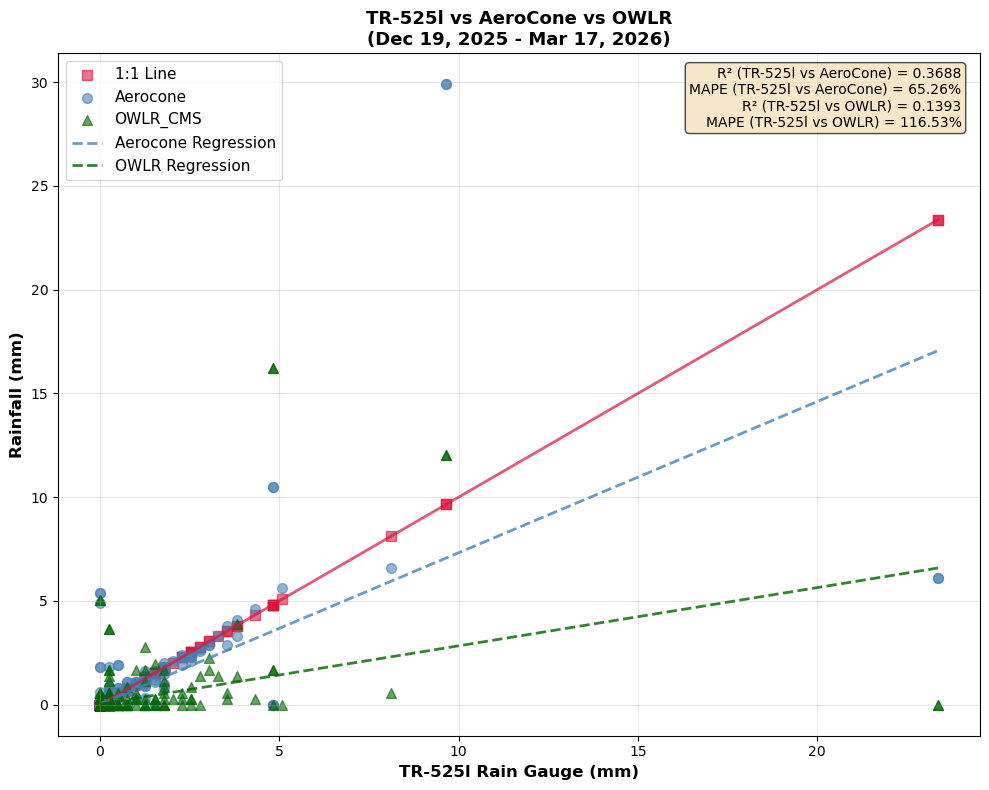

In [4]:
# CORMP (X-axis) vs Davis and OWLR_CMS (Y-axis) — Full Period Comparison
# December 19th, 2025 - March 17th, 2026

print("=" * 70)
print("FULL PERIOD ANALYSIS: CORMP vs Davis vs OWLR_CMS")
print("December 19th, 2025 - March 17th, 2026")
print("=" * 70)

# Use the already-filtered datasets from the initial load
print(f"\nData summary:")
print(f"  CORMP records: {len(cormp)}")
print(f"  Davis records: {len(davis)}")
print(f"  OWLR_CMS records: {len(rain0)}")

# Round all to nearest HOUR for alignment
cormp_full = cormp.copy()
davis_full = davis.copy()
rain0_full = rain0.copy()

cormp_full['datetime'] = cormp_full['datetime'].dt.floor('h')
davis_full['datetime'] = davis_full['datetime'].dt.floor('h')
rain0_full['datetime'] = rain0_full['datetime'].dt.floor('h')

# Merge datasets on datetime
merged_full = pd.merge(cormp_full, davis_full, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_full = pd.merge(merged_full, rain0_full, on='datetime', how='outer')
merged_full = merged_full.rename(columns={'rain_mm': 'rain_mm_owlr_cms'})

print(f"\nMerged dataset shape: {merged_full.shape}")

# Compute correlations, statistics, and MAPEs
mape_cd = float('nan')
mape_co = float('nan')
r2_cd = float('nan')
r2_cr = float('nan')

if not merged_full.empty:
    from scipy import stats
    
    # CORMP vs Davis
    cormp_davis_data = merged_full[merged_full['rain_mm_cormp'].notna() & merged_full['rain_mm_davis'].notna()]
    if not cormp_davis_data.empty:
        corr_cd = cormp_davis_data['rain_mm_cormp'].corr(cormp_davis_data['rain_mm_davis'])
        r2_cd = corr_cd**2
        slope_cd, intercept_cd, _, _, _ = stats.linregress(cormp_davis_data['rain_mm_cormp'], cormp_davis_data['rain_mm_davis'])

        # MAPE (CORMP as reference)
        mape_mask_cd = cormp_davis_data['rain_mm_cormp'] != 0
        if mape_mask_cd.any():
            mape_cd = np.mean(
                np.abs(
                    (cormp_davis_data.loc[mape_mask_cd, 'rain_mm_cormp'] - cormp_davis_data.loc[mape_mask_cd, 'rain_mm_davis'])
                    / cormp_davis_data.loc[mape_mask_cd, 'rain_mm_cormp']
                )
            ) * 100

        print(f"\nCORP vs Davis:")
        print(f"  Pearson Correlation: {corr_cd:.4f}")
        print(f"  R²: {r2_cd:.4f}")
        print(f"  Slope: {slope_cd:.4f}")
        if pd.notna(mape_cd):
            print(f"  MAPE: {mape_cd:.2f}%")
        else:
            print("  MAPE: undefined")
    
    # CORMP vs OWLR_CMS
    cormp_rain0_data = merged_full[merged_full['rain_mm_cormp'].notna() & merged_full['rain_mm_owlr_cms'].notna()]
    if not cormp_rain0_data.empty:
        corr_cr = cormp_rain0_data['rain_mm_cormp'].corr(cormp_rain0_data['rain_mm_owlr_cms'])
        r2_cr = corr_cr**2
        slope_cr, intercept_cr, _, _, _ = stats.linregress(cormp_rain0_data['rain_mm_cormp'], cormp_rain0_data['rain_mm_owlr_cms'])

        # MAPE (CORMP as reference)
        mape_mask_co = cormp_rain0_data['rain_mm_cormp'] != 0
        if mape_mask_co.any():
            mape_co = np.mean(
                np.abs(
                    (cormp_rain0_data.loc[mape_mask_co, 'rain_mm_cormp'] - cormp_rain0_data.loc[mape_mask_co, 'rain_mm_owlr_cms'])
                    / cormp_rain0_data.loc[mape_mask_co, 'rain_mm_cormp']
                )
            ) * 100

        print(f"\nCORP vs OWLR_CMS:")
        print(f"  Pearson Correlation: {corr_cr:.4f}")
        print(f"  R²: {r2_cr:.4f}")
        print(f"  Slope: {slope_cr:.4f}")
        if pd.notna(mape_co):
            print(f"  MAPE: {mape_co:.2f}%")
        else:
            print("  MAPE: undefined")

# Create scatter plot: CORMP (X-axis) vs Davis and OWLR_CMS (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_full.empty:
    # Plot CORMP data (1:1 line)
    cormp_data = merged_full[merged_full['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'], 
                   s=50, alpha=0.6, color='crimson', label='1:1 Line', marker='s')
        # Draw line through CORMP data
        cormp_sorted = cormp_data.sort_values('rain_mm_cormp')
        plt.plot(cormp_sorted['rain_mm_cormp'], cormp_sorted['rain_mm_cormp'], 
                color='crimson', linewidth=2, alpha=0.7)
        print(f"  Plotted {len(cormp_data)} CORMP data points")
    
    # Plot Davis data
    davis_data = merged_full[merged_full['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'], 
                   s=50, alpha=0.6, color='steelblue', label='Aerocone', marker='o')
        print(f"  Plotted {len(davis_data)} Aerocone data points")
    
    # Plot OWLR_CMS data
    owlr_cms_data = merged_full[merged_full['rain_mm_owlr_cms'].notna()]
    if not owlr_cms_data.empty:
        plt.scatter(owlr_cms_data['rain_mm_cormp'], owlr_cms_data['rain_mm_owlr_cms'], 
                   s=50, alpha=0.6, color='darkgreen', label='OWLR_CMS', marker='^')
        print(f"  Plotted {len(owlr_cms_data)} OWLR_CMS data points")
    
    # Add linear regression lines
    # Get x-axis range for regression line plotting
    all_x = []
    if not cormp_data.empty:
        all_x.extend(cormp_data['rain_mm_cormp'].values)
    if not davis_data.empty:
        all_x.extend(davis_data['rain_mm_cormp'].values)
    if not owlr_cms_data.empty:
        all_x.extend(owlr_cms_data['rain_mm_cormp'].values)
    
    if all_x:
        x_min, x_max = min(all_x), max(all_x)
        x_line = np.array([x_min, x_max])
        
        # Davis regression line
        if not cormp_davis_data.empty:
            y_davis = slope_cd * x_line + intercept_cd
            plt.plot(x_line, y_davis, color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Aerocone Regression')
        
        # OWLR_CMS regression line
        if not cormp_rain0_data.empty:
            y_rain0 = slope_cr * x_line + intercept_cr
            plt.plot(x_line, y_rain0, color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR Regression')

plt.xlabel('TR-525l Rain Gauge (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('TR-525l vs AeroCone vs OWLR\n(Dec 19, 2025 - Mar 17, 2026)', fontsize=13, fontweight='bold')

# Add R² and MAPE annotation to plot
ax = plt.gca()
annotation_lines = []
if pd.notna(r2_cd):
    annotation_lines.append(f"R² (TR-525l vs AeroCone) = {r2_cd:.4f}")
if pd.notna(mape_cd):
    annotation_lines.append(f"MAPE (TR-525l vs AeroCone) = {mape_cd:.2f}%")
else:
    annotation_lines.append("MAPE (TR-525l vs AeroCone) = undefined")
if pd.notna(r2_cr):
    annotation_lines.append(f"R² (TR-525l vs OWLR) = {r2_cr:.4f}")
if pd.notna(mape_co):
    annotation_lines.append(f"MAPE (TR-525l vs OWLR) = {mape_co:.2f}%")
else:
    annotation_lines.append("MAPE (TR-525l vs OWLR) = undefined")
ax.text(
    0.98, 0.98,
    '\n'.join(annotation_lines),
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FULL PERIOD ANALYSIS: CORMP vs OWLR_CMS (+ Davis points)
December 19th, 2025 - March 17th, 2026

Data summary:
  CORMP records: 2113
  Davis records: 2113
  OWLR_CMS records: 2293

Merged dataset shape: (2304, 4)

CORMP vs OWLR_CMS:
  Pearson Correlation: 0.3732
  R²: 0.1393
  Slope: 0.2807

Generating scatter plot...
  Plotted 2304 CORMP points
  Plotted 2293 OWLR_CMS points
  Plotted 2304 Davis points


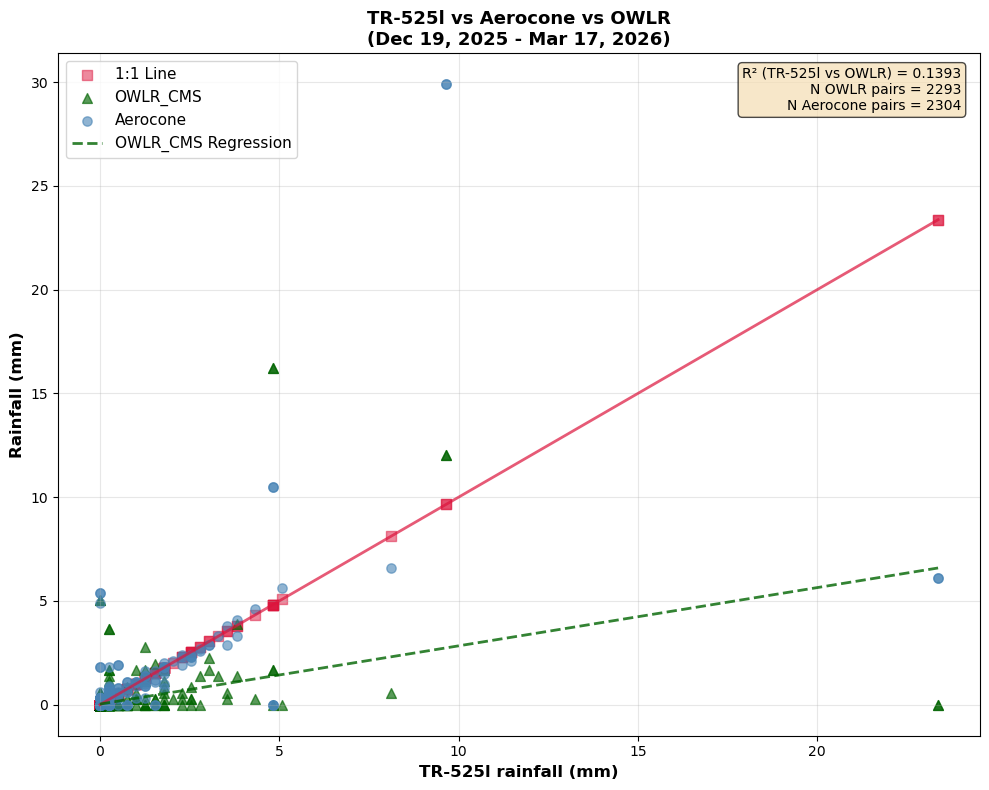


Generating log-log scatter plot...


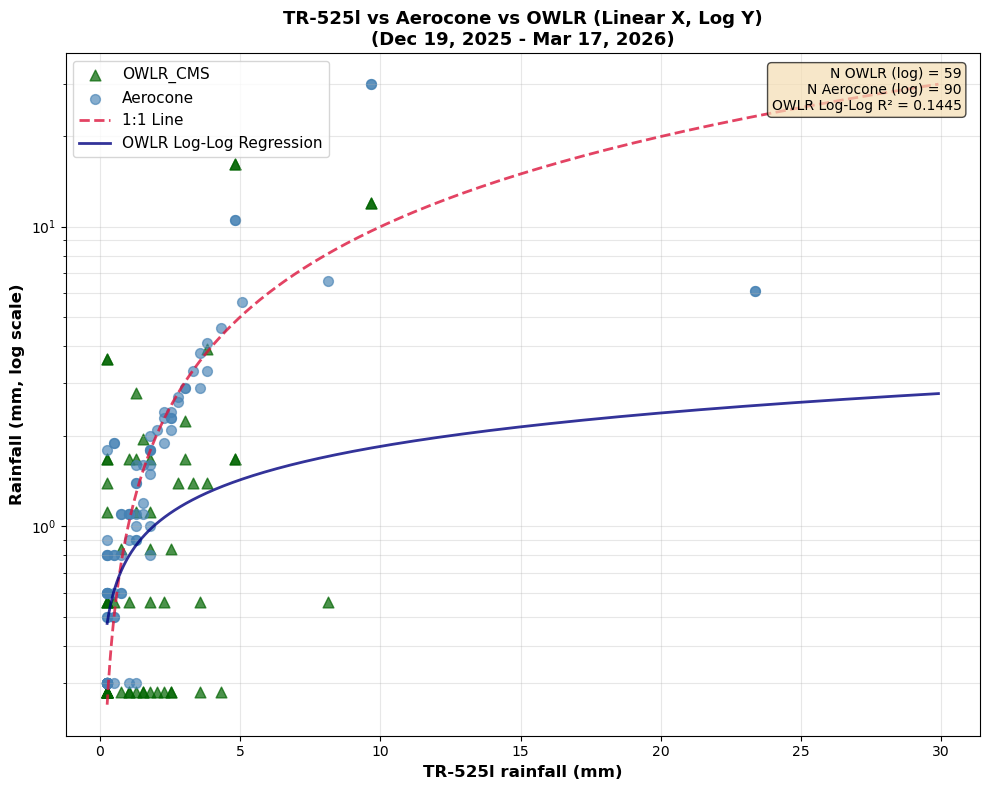

In [5]:
# CORMP (X-axis) vs OWLR_CMS and Davis (Y-axis) — Full Period Comparison
# December 19th, 2025 - March 17th, 2026

print("=" * 70)
print("FULL PERIOD ANALYSIS: CORMP vs OWLR_CMS (+ Davis points)")
print("December 19th, 2025 - March 17th, 2026")
print("=" * 70)

print(f"\nData summary:")
print(f"  CORMP records: {len(cormp)}")
print(f"  Davis records: {len(davis)}")
print(f"  OWLR_CMS records: {len(rain0)}")

# Round all to nearest HOUR for alignment
cormp_full_rain0 = cormp.copy()
rain0_full_only = rain0.copy()
davis_full_only = davis.copy()

cormp_full_rain0['datetime'] = cormp_full_rain0['datetime'].dt.floor('h')
rain0_full_only['datetime'] = rain0_full_only['datetime'].dt.floor('h')
davis_full_only['datetime'] = davis_full_only['datetime'].dt.floor('h')

# Merge datasets on datetime with explicit rainfall column names
merged_rain0_only = pd.merge(
    cormp_full_rain0[['datetime', 'rain_mm']].rename(columns={'rain_mm': 'rain_mm_cormp'}),
    rain0_full_only[['datetime', 'rain_mm']].rename(columns={'rain_mm': 'rain_mm_owlr_cms'}),
    on='datetime',
    how='outer'
)
merged_rain0_only = pd.merge(
    merged_rain0_only,
    davis_full_only[['datetime', 'rain_mm']].rename(columns={'rain_mm': 'rain_mm_davis'}),
    on='datetime',
    how='outer'
)

print(f"\nMerged dataset shape: {merged_rain0_only.shape}")

# Compute OWLR correlation statistics against CORMP
r2_co_only = float('nan')
if not merged_rain0_only.empty:
    from scipy import stats
    cormp_owlr_cms_data_only = merged_rain0_only[
        merged_rain0_only['rain_mm_cormp'].notna() & merged_rain0_only['rain_mm_owlr_cms'].notna()
    ]
    if not cormp_owlr_cms_data_only.empty:
        corr_co_only = cormp_owlr_cms_data_only['rain_mm_cormp'].corr(cormp_owlr_cms_data_only['rain_mm_owlr_cms'])
        r2_co_only = corr_co_only**2
        slope_co_only, intercept_co_only, _, _, _ = stats.linregress(
            cormp_owlr_cms_data_only['rain_mm_cormp'],
            cormp_owlr_cms_data_only['rain_mm_owlr_cms']
        )
        print(f"\nCORMP vs OWLR_CMS:")
        print(f"  Pearson Correlation: {corr_co_only:.4f}")
        print(f"  R²: {r2_co_only:.4f}")
        print(f"  Slope: {slope_co_only:.4f}")

# Create scatter plot: CORMP (X-axis) vs OWLR_CMS and Davis (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_rain0_only.empty:
    cormp_data_rain0 = merged_rain0_only[merged_rain0_only['rain_mm_cormp'].notna()]
    if not cormp_data_rain0.empty:
        plt.scatter(
            cormp_data_rain0['rain_mm_cormp'],
            cormp_data_rain0['rain_mm_cormp'],
            s=45,
            alpha=0.5,
            color='crimson',
            label='1:1 Line',
            marker='s'
        )
        cormp_sorted_rain0 = cormp_data_rain0.sort_values('rain_mm_cormp')
        plt.plot(
            cormp_sorted_rain0['rain_mm_cormp'],
            cormp_sorted_rain0['rain_mm_cormp'],
            color='crimson',
            linewidth=2,
            alpha=0.7
        )
        print(f"  Plotted {len(cormp_data_rain0)} CORMP points")

    owlr_cms_data_only = merged_rain0_only[
        merged_rain0_only['rain_mm_cormp'].notna() & merged_rain0_only['rain_mm_owlr_cms'].notna()
    ]
    if not owlr_cms_data_only.empty:
        plt.scatter(
            owlr_cms_data_only['rain_mm_cormp'],
            owlr_cms_data_only['rain_mm_owlr_cms'],
            s=50,
            alpha=0.65,
            color='darkgreen',
            label='OWLR_CMS',
            marker='^'
        )
        print(f"  Plotted {len(owlr_cms_data_only)} OWLR_CMS points")

    davis_data_only = merged_rain0_only[
        merged_rain0_only['rain_mm_cormp'].notna() & merged_rain0_only['rain_mm_davis'].notna()
    ]
    if not davis_data_only.empty:
        plt.scatter(
            davis_data_only['rain_mm_cormp'],
            davis_data_only['rain_mm_davis'],
            s=45,
            alpha=0.6,
            color='steelblue',
            label='Aerocone',
            marker='o'
        )
        print(f"  Plotted {len(davis_data_only)} Davis points")

    if 'slope_co_only' in locals() and 'intercept_co_only' in locals() and not owlr_cms_data_only.empty:
        x_min_owlr_cms = owlr_cms_data_only['rain_mm_cormp'].min()
        x_max_owlr_cms = owlr_cms_data_only['rain_mm_cormp'].max()
        x_line_owlr_cms = np.array([x_min_owlr_cms, x_max_owlr_cms])
        y_owlr_cms_only = slope_co_only * x_line_owlr_cms + intercept_co_only
        plt.plot(
            x_line_owlr_cms,
            y_owlr_cms_only,
            color='darkgreen',
            linewidth=2,
            alpha=0.8,
            linestyle='--',
            label='OWLR_CMS Regression'
        )

ax = plt.gca()
annotation_lines = []
if pd.notna(r2_co_only):
    n_pairs = len(cormp_owlr_cms_data_only) if 'cormp_owlr_cms_data_only' in locals() else 0
    annotation_lines.append(f"R² (TR-525l vs OWLR) = {r2_co_only:.4f}")
    annotation_lines.append(f"N OWLR pairs = {n_pairs}")
if 'davis_data_only' in locals():
    annotation_lines.append(f"N Aerocone pairs = {len(davis_data_only)}")
if annotation_lines:
    ax.text(
        0.98, 0.98,
        '\n'.join(annotation_lines),
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    )

plt.xlabel('TR-525l rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('TR-525l vs Aerocone vs OWLR\n(Dec 19, 2025 - Mar 17, 2026)', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create log-log scatter plot using overlapping positive rainfall pairs
print(f"\nGenerating log-log scatter plot...")
positive_pairs_owlr = pd.DataFrame()
positive_pairs_davis = pd.DataFrame()

if 'cormp_owlr_cms_data_only' in locals():
    positive_pairs_owlr = cormp_owlr_cms_data_only[
        (cormp_owlr_cms_data_only['rain_mm_cormp'] > 0) &
        (cormp_owlr_cms_data_only['rain_mm_owlr_cms'] > 0)
    ].copy()
if 'davis_data_only' in locals():
    positive_pairs_davis = davis_data_only[
        (davis_data_only['rain_mm_cormp'] > 0) &
        (davis_data_only['rain_mm_davis'] > 0)
    ].copy()

if positive_pairs_owlr.empty and positive_pairs_davis.empty:
    print('  No overlapping positive rainfall pairs available for a log-log plot.')
else:
    plt.figure(figsize=(10, 8))

    if not positive_pairs_owlr.empty:
        plt.scatter(
            positive_pairs_owlr['rain_mm_cormp'],
            positive_pairs_owlr['rain_mm_owlr_cms'],
            s=60,
            alpha=0.7,
            color='darkgreen',
            label='OWLR_CMS',
            marker='^'
        )

    if not positive_pairs_davis.empty:
        plt.scatter(
            positive_pairs_davis['rain_mm_cormp'],
            positive_pairs_davis['rain_mm_davis'],
            s=50,
            alpha=0.65,
            color='steelblue',
            label='Aerocone',
            marker='o'
        )

    positive_x_values = []
    positive_y_values = []
    if not positive_pairs_owlr.empty:
        positive_x_values.extend(positive_pairs_owlr['rain_mm_cormp'].tolist())
        positive_y_values.extend(positive_pairs_owlr['rain_mm_owlr_cms'].tolist())
    if not positive_pairs_davis.empty:
        positive_x_values.extend(positive_pairs_davis['rain_mm_cormp'].tolist())
        positive_y_values.extend(positive_pairs_davis['rain_mm_davis'].tolist())

    min_val = min(min(positive_x_values), min(positive_y_values))
    max_val = max(max(positive_x_values), max(positive_y_values))
    reference_line = np.logspace(np.log10(min_val), np.log10(max_val), 200)
    plt.plot(
        reference_line,
        reference_line,
        color='crimson',
        linewidth=2,
        alpha=0.8,
        linestyle='--',
        label='1:1 Line'
    )

    r2_log = float('nan')
    if len(positive_pairs_owlr) >= 2 and 'stats' in locals():
        log_x = np.log10(positive_pairs_owlr['rain_mm_cormp'])
        log_y = np.log10(positive_pairs_owlr['rain_mm_owlr_cms'])
        slope_log, intercept_log, r_value_log, _, _ = stats.linregress(log_x, log_y)
        regression_line = 10 ** (intercept_log + slope_log * np.log10(reference_line))
        plt.plot(
            reference_line,
            regression_line,
            color='navy',
            linewidth=2,
            alpha=0.8,
            label='OWLR Log-Log Regression'
        )
        r2_log = r_value_log**2

    annotation = []
    annotation.append(f"N OWLR (log) = {len(positive_pairs_owlr)}")
    annotation.append(f"N Aerocone (log) = {len(positive_pairs_davis)}")
    if pd.notna(r2_log):
        annotation.append(f"OWLR Log-Log R² = {r2_log:.4f}")
    ax = plt.gca()
    ax.text(
        0.98, 0.98,
        '\n'.join(annotation),
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    )

    plt.yscale('log')
    plt.xlabel('TR-525l rainfall (mm)', fontsize=12, fontweight='bold')
    plt.ylabel('Rainfall (mm, log scale)', fontsize=12, fontweight='bold')
    plt.title('TR-525l vs Aerocone vs OWLR (Linear X, Log Y)\n(Dec 19, 2025 - Mar 17, 2026)', fontsize=13, fontweight='bold')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()

Filtering January 3rd data...
  CORMP: 24 hourly records
  Davis: 24 hourly records
  OWLR_CMS: 24 hourly records


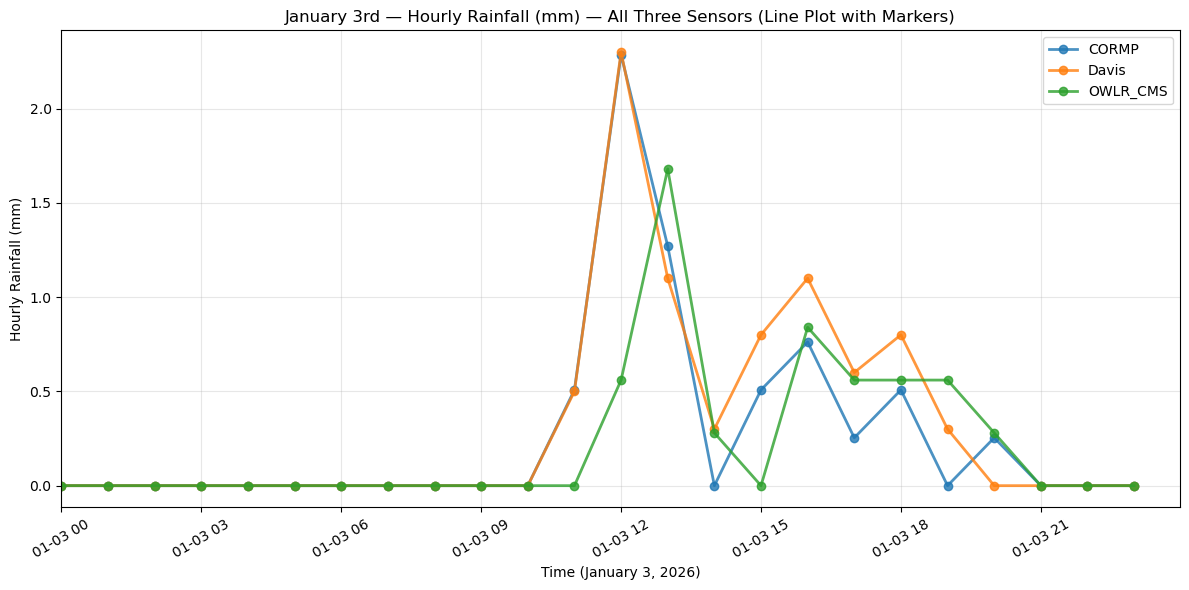

In [6]:

# View of January 3rd, 2026 — All three sensors

jan3_start = pd.to_datetime('2026-01-03 00:00')
jan3_end = pd.to_datetime('2026-01-03 23:59')

print("Filtering January 3rd data...")
cormp_jan3 = cormp[(cormp['datetime'] >= jan3_start) & (cormp['datetime'] <= jan3_end)].reset_index(drop=True)
davis_jan3 = davis[(davis['datetime'] >= jan3_start) & (davis['datetime'] <= jan3_end)].reset_index(drop=True)
rain0_jan3 = rain0[(rain0['datetime'] >= jan3_start) & (rain0['datetime'] <= jan3_end)].reset_index(drop=True)

print(f"  CORMP: {len(cormp_jan3)} hourly records")
print(f"  Davis: {len(davis_jan3)} hourly records")
print(f"  OWLR_CMS: {len(rain0_jan3)} hourly records")

plt.figure(figsize=(12,6))
if not cormp_jan3.empty:
    plt.plot(cormp_jan3['datetime'], cormp_jan3['rain_mm'], label='CORMP', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not davis_jan3.empty:
    plt.plot(davis_jan3['datetime'], davis_jan3['rain_mm'], label='Davis', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not rain0_jan3.empty:
    plt.plot(rain0_jan3['datetime'], rain0_jan3['rain_mm'], label='OWLR_CMS', marker='o', linewidth=2, markersize=6, alpha=0.8)

plt.xlabel('Time (January 3, 2026)')
plt.ylabel('Hourly Rainfall (mm)')
plt.title('January 3rd — Hourly Rainfall (mm) — All Three Sensors (Line Plot with Markers)')
plt.legend()
plt.xlim(jan3_start, jan3_end)
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Direct comparison between TR525l and OWLR with adjusted points. 

ANALYSIS 3: precip_CORMP vs OWLR_CMS Comparison

Before datetime alignment:
  CORMP shape: (2112, 2)
  OWLR_CMS shape: (2291, 6)

After rounding to nearest hour:
  CORMP first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]
  OWLR_CMS first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]

Overlapping hourly timestamps: 2101 hours
Merged dataset shape: (2291, 7)

Pearson Correlation: 0.3732
R^2 (Coefficient of Determination): 0.1393
Correction factor (multiply OWLR_CMS by): 0.4961
MAPE: 116.53%

Generating scatter plot...
  Plotted 2291 data points


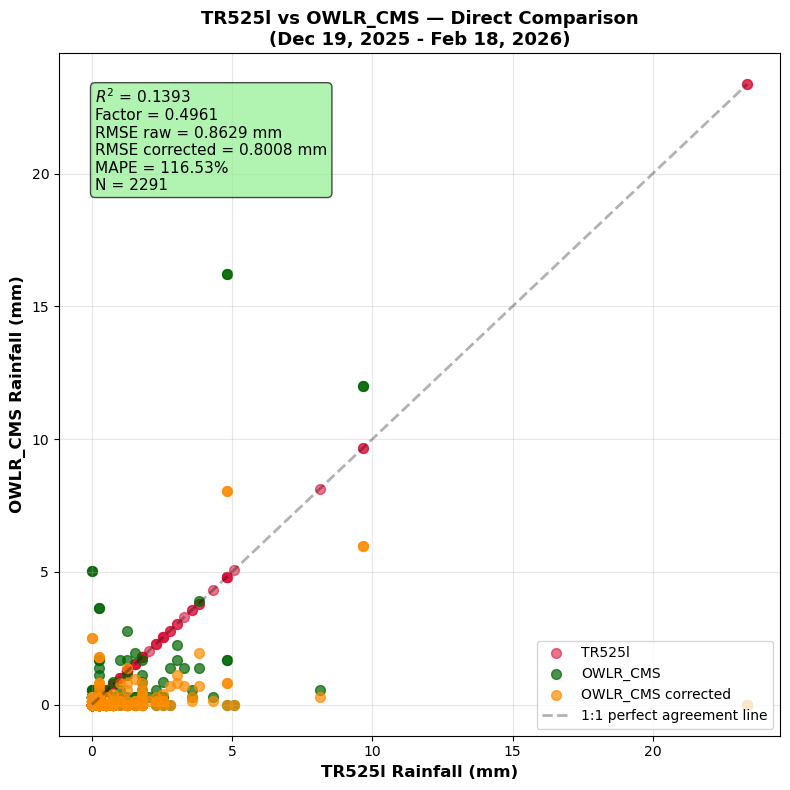

In [10]:
# precip_CORMP vs OWLR_CMS — Direct Sensor Comparison
# Merge datasets by datetime, compute correlation (R^2), and plot

print("=" * 70)
print("ANALYSIS 3: precip_CORMP vs OWLR_CMS Comparison")
print("=" * 70)

# Reload and process both datasets for clean analysis
cormp_only = load_and_process(file_1, assume_inches=True, already_hourly=False)
rain0_cormp = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-03-17 08:00')

cormp_only = cormp_only[(cormp_only['datetime'] >= start) & (cormp_only['datetime'] <= end)].reset_index(drop=True)
rain0_cormp = rain0_cormp[(rain0_cormp['datetime'] >= start) & (rain0_cormp['datetime'] <= end)].reset_index(drop=True)

print(f"\nBefore datetime alignment:")
print(f"  CORMP shape: {cormp_only.shape}")
print(f"  OWLR_CMS shape: {rain0_cormp.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
cormp_only['datetime'] = cormp_only['datetime'].dt.floor('h')
rain0_cormp['datetime'] = rain0_cormp['datetime'].dt.floor('h')

print(f"\nAfter rounding to nearest hour:")
print(f"  CORMP first 5 timestamps: {cormp_only['datetime'].head().tolist()}")
print(f"  OWLR_CMS first 5 timestamps: {rain0_cormp['datetime'].head().tolist()}")

# Check for overlapping datetimes
cormp_dates = set(cormp_only['datetime'])
rain0_dates = set(rain0_cormp['datetime'])
overlap = cormp_dates.intersection(rain0_dates)
print(f"\nOverlapping hourly timestamps: {len(overlap)} hours")

# Align datasets on datetime for direct comparison
merged_cr_only = pd.merge(rain0_cormp, cormp_only, on='datetime', how='inner', suffixes=('_owlr','_cormp'))
print(f"Merged dataset shape: {merged_cr_only.shape}")

# Compute correlation, R^2, correction factor, and MAPE
if not merged_cr_only.empty:
    from scipy import stats
    corr_cr = merged_cr_only['rain_mm_owlr'].corr(merged_cr_only['rain_mm_cormp'])
    r2_cr = corr_cr**2 if pd.notna(corr_cr) else float('nan')
    # Regression for correction factor: CORMP as reference (x = owlr, y = cormp)
    slope_corr, intercept_corr, _, _, _ = stats.linregress(
        merged_cr_only['rain_mm_owlr'], merged_cr_only['rain_mm_cormp']
    )

    # MAPE using CORMP as reference; avoid division by zero
    mape_mask = merged_cr_only['rain_mm_cormp'] != 0
    if mape_mask.any():
        mape = np.mean(
            np.abs(
                (merged_cr_only.loc[mape_mask, 'rain_mm_cormp'] - merged_cr_only.loc[mape_mask, 'rain_mm_owlr'])
                / merged_cr_only.loc[mape_mask, 'rain_mm_cormp']
            )
        ) * 100
    else:
        mape = float('nan')

    print(f"\nPearson Correlation: {corr_cr:.4f}")
    print(f"R^2 (Coefficient of Determination): {r2_cr:.4f}")
    print(f"Correction factor (multiply OWLR_CMS by): {slope_corr:.4f}")
    if pd.notna(mape):
        print(f"MAPE: {mape:.2f}%")
    else:
        print("MAPE: undefined (no non-zero CORMP values)")
else:
    r2_cr = float('nan')
    slope_corr = float('nan')
    intercept_corr = float('nan')
    mape = float('nan')
    print("No overlapping data found!")

# Create scatter plot: precip_CORMP (X-axis) vs OWLR_CMS (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_cr_only.empty:
    # CORMP reference points (1:1)
    plt.scatter(merged_cr_only['rain_mm_cormp'], merged_cr_only['rain_mm_cormp'],
                s=50, alpha=0.6, color='crimson', label='TR525l')
    plt.scatter(merged_cr_only['rain_mm_cormp'], merged_cr_only['rain_mm_owlr'], s=50, alpha=0.7, color='darkgreen', label='OWLR_CMS')
    # Corrected OWLR_CMS using the correction factor
    corrected_owlr = merged_cr_only['rain_mm_owlr'] * slope_corr
    plt.scatter(merged_cr_only['rain_mm_cormp'], corrected_owlr, s=50, alpha=0.7, color='darkorange', label='OWLR_CMS corrected')
    print(f"  Plotted {len(merged_cr_only)} data points")
else:
    print("  No data to plot - no overlapping datetimes found")

plt.xlabel('TR525l Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('OWLR_CMS Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('TR525l vs OWLR_CMS — Direct Comparison\n(Dec 19, 2025 - Feb 18, 2026)', fontsize=13, fontweight='bold')

# Annotate R^2, correction error, and MAPE on plot
try:
    ax = plt.gca()
    if not merged_cr_only.empty and pd.notna(r2_cr):
        rmse_raw = np.sqrt(np.mean((merged_cr_only['rain_mm_owlr'] - merged_cr_only['rain_mm_cormp'])**2))
        rmse_corr = np.sqrt(np.mean((corrected_owlr - merged_cr_only['rain_mm_cormp'])**2))
        mape_text = f"\nMAPE = {mape:.2f}%" if pd.notna(mape) else "\nMAPE = undefined"
        ax.text(0.05, 0.95,
    
               f'$R^2$ = {r2_cr:.4f}\nFactor = {slope_corr:.4f}\nRMSE raw = {rmse_raw:.4f} mm\nRMSE corrected = {rmse_corr:.4f} mm{mape_text}\nN = {len(merged_cr_only)}',
                transform=ax.transAxes, fontsize=11, va='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_cr_only.empty:
    max_val = max(merged_cr_only['rain_mm_owlr'].max(), merged_cr_only['rain_mm_cormp'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')
    plt.legend(loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Rainfall Event Plots

The following plots show analysis from specific rain events during deployment. 



ANALYSIS 5: January 18th, 2026 — CORMP vs Davis and rainfall_0000

January 18th, 2026 Data:
  CORMP records: 12
  Davis records: 12
  rainfall_0000 records: 12

Merged dataset shape: (12, 8)

Generating scatter plot...
  Plotted 12 TR525l data points
  Plotted 12 Aerocone data points
  Plotted 12 OWLR data points


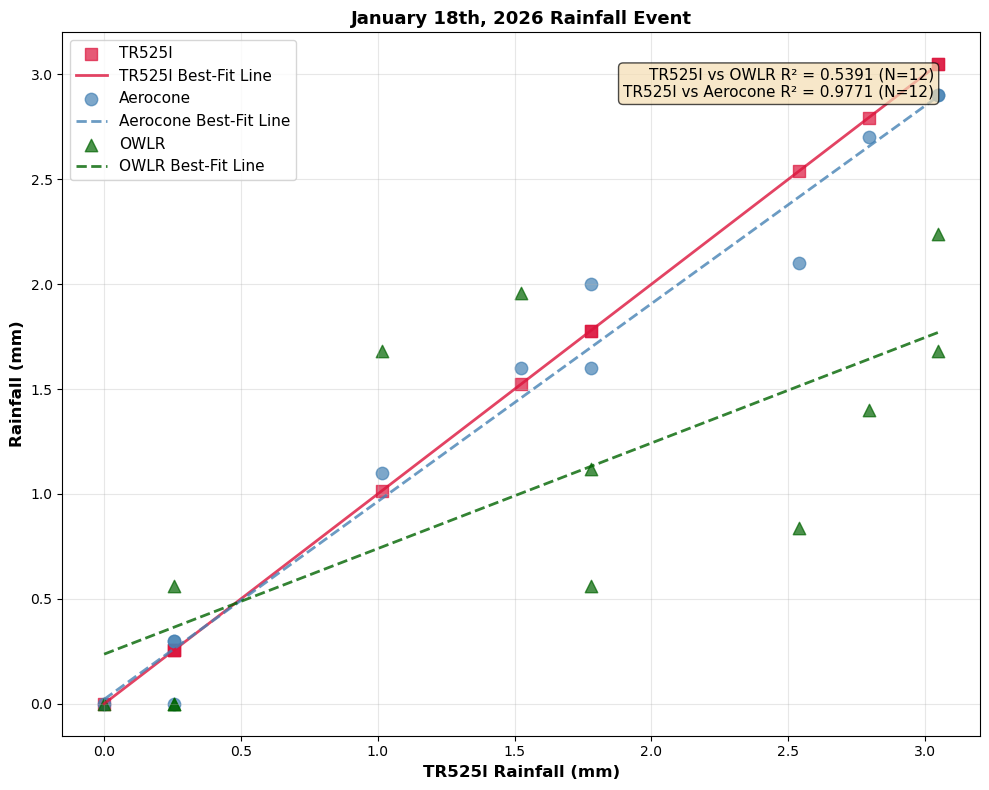


Summary Statistics for January 18th:
CORMP - Min: 0.0000, Max: 3.0480, Mean: 1.5240
Davis - Min: 0.0000, Max: 2.9000, Mean: 1.4583
rainfall_0000 - Min: 0.0000, Max: 2.2400, Mean: 1.0033


In [32]:
# January 18th, 2026 — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 5: January 18th, 2026 — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_jan18 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_jan18 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_jan18 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

jan18_start = pd.to_datetime('2026-01-18 08:00')
jan18_end = pd.to_datetime('2026-01-18 19:00')

cormp_jan18 = cormp_jan18[(cormp_jan18['datetime'] >= jan18_start) & (cormp_jan18['datetime'] <= jan18_end)].reset_index(drop=True)
davis_jan18 = davis_jan18[(davis_jan18['datetime'] >= jan18_start) & (davis_jan18['datetime'] <= jan18_end)].reset_index(drop=True)
rain0_jan18 = rain0_jan18[(rain0_jan18['datetime'] >= jan18_start) & (rain0_jan18['datetime'] <= jan18_end)].reset_index(drop=True)

print(f"\nJanuary 18th, 2026 Data:")
print(f"  CORMP records: {len(cormp_jan18)}")
print(f"  Davis records: {len(davis_jan18)}")
print(f"  rainfall_0000 records: {len(rain0_jan18)}")

# Round all to nearest HOUR to align hourly data
cormp_jan18['datetime'] = cormp_jan18['datetime'].dt.floor('h')
davis_jan18['datetime'] = davis_jan18['datetime'].dt.floor('h')
rain0_jan18['datetime'] = rain0_jan18['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_jan18 = pd.merge(cormp_jan18, davis_jan18, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_jan18 = pd.merge(merged_jan18, rain0_jan18, on='datetime', how='outer')
merged_jan18 = merged_jan18.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_jan18.shape}")

# Compute R2 values for annotation
r2_cormp_rain0_jan18 = float('nan')
r2_cormp_davis_jan18 = float('nan')
n_cormp_rain0_jan18 = 0
n_cormp_davis_jan18 = 0
if not merged_jan18.empty:
    cormp_rain0_jan18 = merged_jan18[
        merged_jan18['rain_mm_cormp'].notna() & merged_jan18['rain_mm_rain0'].notna()
    ]
    n_cormp_rain0_jan18 = len(cormp_rain0_jan18)
    if n_cormp_rain0_jan18 > 0:
        corr_cormp_rain0_jan18 = cormp_rain0_jan18['rain_mm_cormp'].corr(cormp_rain0_jan18['rain_mm_rain0'])
        r2_cormp_rain0_jan18 = corr_cormp_rain0_jan18**2

    cormp_davis_jan18 = merged_jan18[
        merged_jan18['rain_mm_cormp'].notna() & merged_jan18['rain_mm_davis'].notna()
    ]
    n_cormp_davis_jan18 = len(cormp_davis_jan18)
    if n_cormp_davis_jan18 > 0:
        corr_cormp_davis_jan18 = cormp_davis_jan18['rain_mm_cormp'].corr(cormp_davis_jan18['rain_mm_davis'])
        r2_cormp_davis_jan18 = corr_cormp_davis_jan18**2

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_jan18.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_jan18[merged_jan18['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'],
                   s=80, alpha=0.7, color='crimson', label='TR525l', marker='s')
        print(f"  Plotted {len(cormp_data)} TR525l data points")
        x_cormp = cormp_data['rain_mm_cormp']
        y_cormp = cormp_data['rain_mm_cormp']
        slope_cormp, intercept_cormp = np.polyfit(x_cormp, y_cormp, 1)
        x_line_cormp = np.array([x_cormp.min(), x_cormp.max()])
        y_line_cormp = slope_cormp * x_line_cormp + intercept_cormp
        plt.plot(x_line_cormp, y_line_cormp,
                 color='crimson', linewidth=2, alpha=0.8, label='TR525l Best-Fit Line')

    # Plot Davis data and best-fit line
    davis_data = merged_jan18[merged_jan18['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'],
                   s=80, alpha=0.7, color='steelblue', label='Aerocone', marker='o')
        print(f"  Plotted {len(davis_data)} Aerocone data points")
        davis_fit = merged_jan18[
            merged_jan18['rain_mm_cormp'].notna() & merged_jan18['rain_mm_davis'].notna()
        ]
        if len(davis_fit) >= 2:
            x_fit_davis = davis_fit['rain_mm_cormp']
            y_fit_davis = davis_fit['rain_mm_davis']
            slope_davis, intercept_davis = np.polyfit(x_fit_davis, y_fit_davis, 1)
            x_line_davis = np.array([x_fit_davis.min(), x_fit_davis.max()])
            y_line_davis = slope_davis * x_line_davis + intercept_davis
            plt.plot(x_line_davis, y_line_davis,
                     color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Aerocone Best-Fit Line')

    # Plot OWLR data and best-fit line
    rain0_data = merged_jan18[merged_jan18['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'],
                   s=80, alpha=0.7, color='darkgreen', label='OWLR', marker='^')
        print(f"  Plotted {len(rain0_data)} OWLR data points")
        rain0_fit = merged_jan18[
            merged_jan18['rain_mm_cormp'].notna() & merged_jan18['rain_mm_rain0'].notna()
        ]
        if len(rain0_fit) >= 2:
            x_fit_rain0 = rain0_fit['rain_mm_cormp']
            y_fit_rain0 = rain0_fit['rain_mm_rain0']
            slope_rain0, intercept_rain0 = np.polyfit(x_fit_rain0, y_fit_rain0, 1)
            x_line_rain0 = np.array([x_fit_rain0.min(), x_fit_rain0.max()])
            y_line_rain0 = slope_rain0 * x_line_rain0 + intercept_rain0
            plt.plot(x_line_rain0, y_line_rain0,
                     color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR Best-Fit Line')

annotation_lines = []
if pd.notna(r2_cormp_rain0_jan18):
    annotation_lines.append(f"TR525l vs OWLR R² = {r2_cormp_rain0_jan18:.4f} (N={n_cormp_rain0_jan18})")
if pd.notna(r2_cormp_davis_jan18):
    annotation_lines.append(f"TR525l vs Aerocone R² = {r2_cormp_davis_jan18:.4f} (N={n_cormp_davis_jan18})")
if annotation_lines:
    ax = plt.gca()
    ax.text(0.95, 0.95, "\n".join(annotation_lines), transform=ax.transAxes, fontsize=11, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.xlabel('TR525l Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('January 18th, 2026 Rainfall Event', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for January 18th:")
print("=" * 70)
if 'rain_mm_cormp' in merged_jan18.columns:
    print(f"CORMP - Min: {merged_jan18['rain_mm_cormp'].min():.4f}, Max: {merged_jan18['rain_mm_cormp'].max():.4f}, Mean: {merged_jan18['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_jan18.columns:
    print(f"Davis - Min: {merged_jan18['rain_mm_davis'].min():.4f}, Max: {merged_jan18['rain_mm_davis'].max():.4f}, Mean: {merged_jan18['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_jan18.columns:
    print(f"rainfall_0000 - Min: {merged_jan18['rain_mm_rain0'].min():.4f}, Max: {merged_jan18['rain_mm_rain0'].max():.4f}, Mean: {merged_jan18['rain_mm_rain0'].mean():.4f}")

ANALYSIS 6: January 3rd 9am - 11pm — CORMP vs Davis and rainfall_0000

January 3rd 9am - 11pm Data:
  CORMP records: 15
  Davis records: 15
  rainfall_0000 records: 15

Merged dataset shape: (15, 8)

Generating scatter plot...
  Plotted 15 TR525l data points
  Plotted 15 Aerocone data points
  Plotted 15 OWLR data points


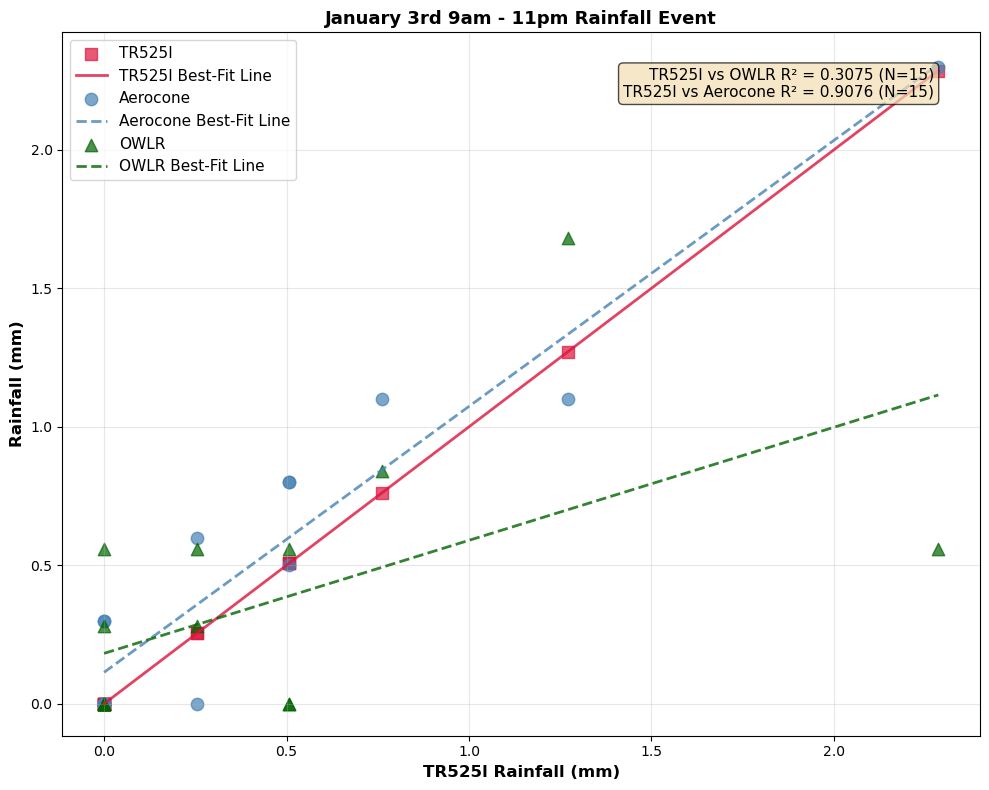


Summary Statistics for January 3rd 9am - 11pm:
CORMP - Min: 0.0000, Max: 2.2860, Mean: 0.4233
Aerocone - Min: 0.0000, Max: 2.3000, Mean: 0.5200
OWLR - Min: 0.0000, Max: 1.6800, Mean: 0.3547


In [30]:
# January 3rd 9am to 11pm — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 6: January 3rd 9am - 11pm — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_jan3 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_jan3 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_jan3 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

jan3_start = pd.to_datetime('2026-01-03 09:00')
jan3_end = pd.to_datetime('2026-01-03 23:00')

cormp_jan3 = cormp_jan3[(cormp_jan3['datetime'] >= jan3_start) & (cormp_jan3['datetime'] <= jan3_end)].reset_index(drop=True)
davis_jan3 = davis_jan3[(davis_jan3['datetime'] >= jan3_start) & (davis_jan3['datetime'] <= jan3_end)].reset_index(drop=True)
rain0_jan3 = rain0_jan3[(rain0_jan3['datetime'] >= jan3_start) & (rain0_jan3['datetime'] <= jan3_end)].reset_index(drop=True)

print(f"\nJanuary 3rd 9am - 11pm Data:")
print(f"  CORMP records: {len(cormp_jan3)}")
print(f"  Davis records: {len(davis_jan3)}")
print(f"  rainfall_0000 records: {len(rain0_jan3)}")

# Round all to nearest HOUR to align hourly data
cormp_jan3['datetime'] = cormp_jan3['datetime'].dt.floor('h')
davis_jan3['datetime'] = davis_jan3['datetime'].dt.floor('h')
rain0_jan3['datetime'] = rain0_jan3['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_jan3 = pd.merge(cormp_jan3, davis_jan3, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_jan3 = pd.merge(merged_jan3, rain0_jan3, on='datetime', how='outer')
merged_jan3 = merged_jan3.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_jan3.shape}")

# Compute R2 values for annotation
r2_cormp_rain0_jan3 = float('nan')
r2_cormp_davis_jan3 = float('nan')
n_cormp_rain0_jan3 = 0
n_cormp_davis_jan3 = 0
if not merged_jan3.empty:
    cormp_rain0_jan3 = merged_jan3[
        merged_jan3['rain_mm_cormp'].notna() & merged_jan3['rain_mm_rain0'].notna()
    ]
    n_cormp_rain0_jan3 = len(cormp_rain0_jan3)
    if n_cormp_rain0_jan3 > 0:
        corr_cormp_rain0_jan3 = cormp_rain0_jan3['rain_mm_cormp'].corr(cormp_rain0_jan3['rain_mm_rain0'])
        r2_cormp_rain0_jan3 = corr_cormp_rain0_jan3**2

    cormp_davis_jan3 = merged_jan3[
        merged_jan3['rain_mm_cormp'].notna() & merged_jan3['rain_mm_davis'].notna()
    ]
    n_cormp_davis_jan3 = len(cormp_davis_jan3)
    if n_cormp_davis_jan3 > 0:
        corr_cormp_davis_jan3 = cormp_davis_jan3['rain_mm_cormp'].corr(cormp_davis_jan3['rain_mm_davis'])
        r2_cormp_davis_jan3 = corr_cormp_davis_jan3**2

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_jan3.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_jan3[merged_jan3['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'],
                   s=80, alpha=0.7, color='crimson', label='TR525l', marker='s')
        print(f"  Plotted {len(cormp_data)} TR525l data points")
        x_cormp = cormp_data['rain_mm_cormp']
        y_cormp = cormp_data['rain_mm_cormp']
        slope_cormp, intercept_cormp = np.polyfit(x_cormp, y_cormp, 1)
        x_line_cormp = np.array([x_cormp.min(), x_cormp.max()])
        y_line_cormp = slope_cormp * x_line_cormp + intercept_cormp
        plt.plot(x_line_cormp, y_line_cormp,
                 color='crimson', linewidth=2, alpha=0.8, label='TR525l Best-Fit Line')

    # Plot Davis data and best-fit line
    davis_data = merged_jan3[merged_jan3['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'],
                   s=80, alpha=0.7, color='steelblue', label='Aerocone', marker='o')
        print(f"  Plotted {len(davis_data)} Aerocone data points")
        davis_fit = merged_jan3[
            merged_jan3['rain_mm_cormp'].notna() & merged_jan3['rain_mm_davis'].notna()
        ]
        if len(davis_fit) >= 2:
            x_fit_davis = davis_fit['rain_mm_cormp']
            y_fit_davis = davis_fit['rain_mm_davis']
            slope_davis, intercept_davis = np.polyfit(x_fit_davis, y_fit_davis, 1)
            x_line_davis = np.array([x_fit_davis.min(), x_fit_davis.max()])
            y_line_davis = slope_davis * x_line_davis + intercept_davis
            plt.plot(x_line_davis, y_line_davis,
                     color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Aerocone Best-Fit Line')

    # Plot rainfall_0000 data and best-fit line
    rain0_data = merged_jan3[merged_jan3['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'],
                   s=80, alpha=0.7, color='darkgreen', label='OWLR', marker='^')
        print(f"  Plotted {len(rain0_data)} OWLR data points")
        rain0_fit = merged_jan3[
            merged_jan3['rain_mm_cormp'].notna() & merged_jan3['rain_mm_rain0'].notna()
        ]
        if len(rain0_fit) >= 2:
            x_fit_rain0 = rain0_fit['rain_mm_cormp']
            y_fit_rain0 = rain0_fit['rain_mm_rain0']
            slope_rain0, intercept_rain0 = np.polyfit(x_fit_rain0, y_fit_rain0, 1)
            x_line_rain0 = np.array([x_fit_rain0.min(), x_fit_rain0.max()])
            y_line_rain0 = slope_rain0 * x_line_rain0 + intercept_rain0
            plt.plot(x_line_rain0, y_line_rain0,
                     color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR Best-Fit Line')

annotation_lines = []
if pd.notna(r2_cormp_rain0_jan3):
    annotation_lines.append(f"TR525l vs OWLR R² = {r2_cormp_rain0_jan3:.4f} (N={n_cormp_rain0_jan3})")
if pd.notna(r2_cormp_davis_jan3):
    annotation_lines.append(f"TR525l vs Aerocone R² = {r2_cormp_davis_jan3:.4f} (N={n_cormp_davis_jan3})")
if annotation_lines:
    ax = plt.gca()
    ax.text(0.95, 0.95, "\n".join(annotation_lines), transform=ax.transAxes, fontsize=11, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.xlabel('TR525l Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('January 3rd 9am - 11pm Rainfall Event', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for January 3rd 9am - 11pm:")
print("=" * 70)
if 'rain_mm_cormp' in merged_jan3.columns:
    print(f"CORMP - Min: {merged_jan3['rain_mm_cormp'].min():.4f}, Max: {merged_jan3['rain_mm_cormp'].max():.4f}, Mean: {merged_jan3['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_jan3.columns:
    print(f"Aerocone - Min: {merged_jan3['rain_mm_davis'].min():.4f}, Max: {merged_jan3['rain_mm_davis'].max():.4f}, Mean: {merged_jan3['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_jan3.columns:
    print(f"OWLR - Min: {merged_jan3['rain_mm_rain0'].min():.4f}, Max: {merged_jan3['rain_mm_rain0'].max():.4f}, Mean: {merged_jan3['rain_mm_rain0'].mean():.4f}")

ANALYSIS 7: January 25th 7am - January 26th 11am — CORMP vs Davis and rainfall_0000

January 25th 7am - January 26th 11am Data:
  CORMP records: 29
  Davis records: 29
  rainfall_0000 records: 29

Merged dataset shape: (29, 8)

Generating scatter plot...
  Plotted 29 TR525l data points
  Plotted 29 Aerocone data points
  Plotted 29 OWLR data points


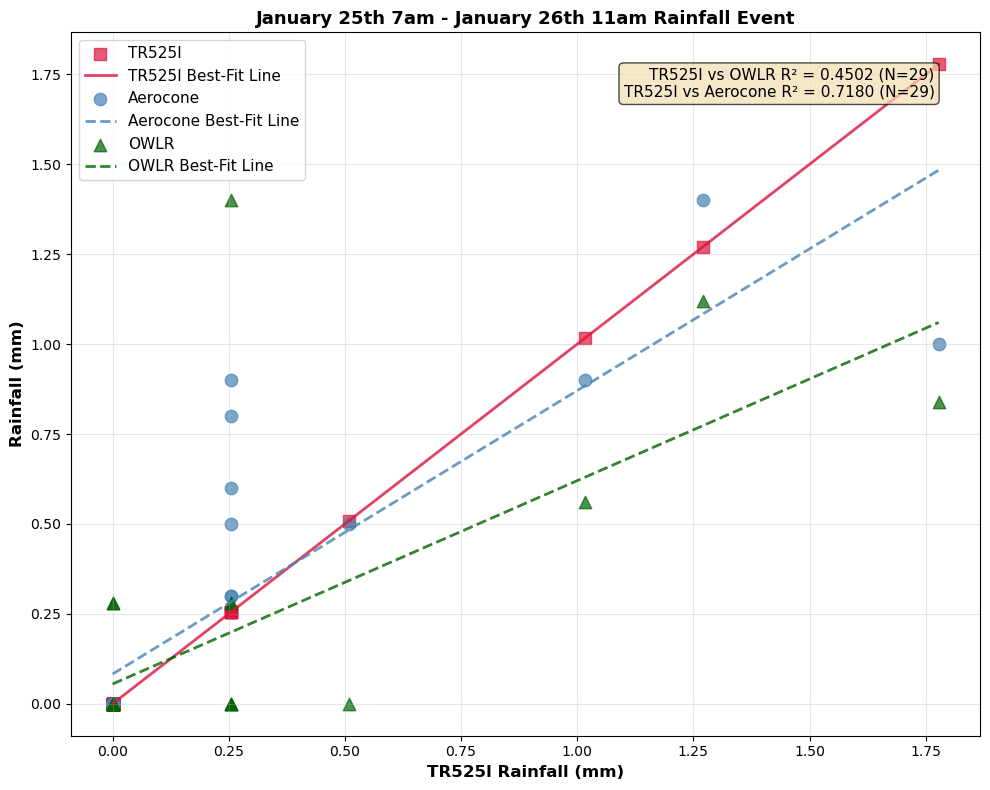


Summary Statistics for January 25th 7am - January 26th 11am:
CORMP - Min: 0.0000, Max: 1.7780, Mean: 0.2102
Davis - Min: 0.0000, Max: 1.4000, Mean: 0.2483
rainfall_0000 - Min: 0.0000, Max: 1.4000, Mean: 0.1738


In [29]:
# January 25th 7am to January 26th 11am — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 7: January 25th 7am - January 26th 11am — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_jan25_26 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_jan25_26 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_jan25_26 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

jan25_start = pd.to_datetime('2026-01-25 07:00')
jan26_end = pd.to_datetime('2026-01-26 11:00')

cormp_jan25_26 = cormp_jan25_26[(cormp_jan25_26['datetime'] >= jan25_start) & (cormp_jan25_26['datetime'] <= jan26_end)].reset_index(drop=True)
davis_jan25_26 = davis_jan25_26[(davis_jan25_26['datetime'] >= jan25_start) & (davis_jan25_26['datetime'] <= jan26_end)].reset_index(drop=True)
rain0_jan25_26 = rain0_jan25_26[(rain0_jan25_26['datetime'] >= jan25_start) & (rain0_jan25_26['datetime'] <= jan26_end)].reset_index(drop=True)

print(f"\nJanuary 25th 7am - January 26th 11am Data:")
print(f"  CORMP records: {len(cormp_jan25_26)}")
print(f"  Davis records: {len(davis_jan25_26)}")
print(f"  rainfall_0000 records: {len(rain0_jan25_26)}")

# Round all to nearest HOUR to align hourly data
cormp_jan25_26['datetime'] = cormp_jan25_26['datetime'].dt.floor('h')
davis_jan25_26['datetime'] = davis_jan25_26['datetime'].dt.floor('h')
rain0_jan25_26['datetime'] = rain0_jan25_26['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_jan25_26 = pd.merge(cormp_jan25_26, davis_jan25_26, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_jan25_26 = pd.merge(merged_jan25_26, rain0_jan25_26, on='datetime', how='outer')
merged_jan25_26 = merged_jan25_26.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_jan25_26.shape}")

# Compute R2 values for annotation
r2_cormp_rain0_jan25 = float('nan')
r2_cormp_davis_jan25 = float('nan')
n_cormp_rain0_jan25 = 0
n_cormp_davis_jan25 = 0
if not merged_jan25_26.empty:
    cormp_rain0_jan25 = merged_jan25_26[
        merged_jan25_26['rain_mm_cormp'].notna() & merged_jan25_26['rain_mm_rain0'].notna()
    ]
    n_cormp_rain0_jan25 = len(cormp_rain0_jan25)
    if n_cormp_rain0_jan25 > 0:
        corr_cormp_rain0_jan25 = cormp_rain0_jan25['rain_mm_cormp'].corr(cormp_rain0_jan25['rain_mm_rain0'])
        r2_cormp_rain0_jan25 = corr_cormp_rain0_jan25**2

    cormp_davis_jan25 = merged_jan25_26[
        merged_jan25_26['rain_mm_cormp'].notna() & merged_jan25_26['rain_mm_davis'].notna()
    ]
    n_cormp_davis_jan25 = len(cormp_davis_jan25)
    if n_cormp_davis_jan25 > 0:
        corr_cormp_davis_jan25 = cormp_davis_jan25['rain_mm_cormp'].corr(cormp_davis_jan25['rain_mm_davis'])
        r2_cormp_davis_jan25 = corr_cormp_davis_jan25**2

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_jan25_26.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_jan25_26[merged_jan25_26['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'],
                   s=80, alpha=0.7, color='crimson', label='TR525l', marker='s')
        print(f"  Plotted {len(cormp_data)} TR525l data points")
        x_cormp = cormp_data['rain_mm_cormp']
        y_cormp = cormp_data['rain_mm_cormp']
        slope_cormp, intercept_cormp = np.polyfit(x_cormp, y_cormp, 1)
        x_line_cormp = np.array([x_cormp.min(), x_cormp.max()])
        y_line_cormp = slope_cormp * x_line_cormp + intercept_cormp
        plt.plot(x_line_cormp, y_line_cormp,
                 color='crimson', linewidth=2, alpha=0.8, label='TR525l Best-Fit Line')

    # Plot Davis data and best-fit line
    davis_data = merged_jan25_26[merged_jan25_26['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'],
                   s=80, alpha=0.7, color='steelblue', label='Aerocone', marker='o')
        print(f"  Plotted {len(davis_data)} Aerocone data points")
        davis_fit = merged_jan25_26[
            merged_jan25_26['rain_mm_cormp'].notna() & merged_jan25_26['rain_mm_davis'].notna()
        ]
        if len(davis_fit) >= 2:
            x_fit_davis = davis_fit['rain_mm_cormp']
            y_fit_davis = davis_fit['rain_mm_davis']
            slope_davis, intercept_davis = np.polyfit(x_fit_davis, y_fit_davis, 1)
            x_line_davis = np.array([x_fit_davis.min(), x_fit_davis.max()])
            y_line_davis = slope_davis * x_line_davis + intercept_davis
            plt.plot(x_line_davis, y_line_davis,
                     color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Aerocone Best-Fit Line')

    # Plot rainfall_0000 data and best-fit line
    rain0_data = merged_jan25_26[merged_jan25_26['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'],
                   s=80, alpha=0.7, color='darkgreen', label='OWLR', marker='^')
        print(f"  Plotted {len(rain0_data)} OWLR data points")
        rain0_fit = merged_jan25_26[
            merged_jan25_26['rain_mm_cormp'].notna() & merged_jan25_26['rain_mm_rain0'].notna()
        ]
        if len(rain0_fit) >= 2:
            x_fit_rain0 = rain0_fit['rain_mm_cormp']
            y_fit_rain0 = rain0_fit['rain_mm_rain0']
            slope_rain0, intercept_rain0 = np.polyfit(x_fit_rain0, y_fit_rain0, 1)
            x_line_rain0 = np.array([x_fit_rain0.min(), x_fit_rain0.max()])
            y_line_rain0 = slope_rain0 * x_line_rain0 + intercept_rain0
            plt.plot(x_line_rain0, y_line_rain0,
                     color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR Best-Fit Line')

annotation_lines = []
if pd.notna(r2_cormp_rain0_jan25):
    annotation_lines.append(f"TR525l vs OWLR R² = {r2_cormp_rain0_jan25:.4f} (N={n_cormp_rain0_jan25})")
if pd.notna(r2_cormp_davis_jan25):
    annotation_lines.append(f"TR525l vs Aerocone R² = {r2_cormp_davis_jan25:.4f} (N={n_cormp_davis_jan25})")
if annotation_lines:
    ax = plt.gca()
    ax.text(0.95, 0.95, "\n".join(annotation_lines), transform=ax.transAxes, fontsize=11, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.xlabel('TR525l Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('January 25th 7am - January 26th 11am Rainfall Event', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for January 25th 7am - January 26th 11am:")
print("=" * 70)
if 'rain_mm_cormp' in merged_jan25_26.columns:
    print(f"CORMP - Min: {merged_jan25_26['rain_mm_cormp'].min():.4f}, Max: {merged_jan25_26['rain_mm_cormp'].max():.4f}, Mean: {merged_jan25_26['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_jan25_26.columns:
    print(f"Davis - Min: {merged_jan25_26['rain_mm_davis'].min():.4f}, Max: {merged_jan25_26['rain_mm_davis'].max():.4f}, Mean: {merged_jan25_26['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_jan25_26.columns:
    print(f"rainfall_0000 - Min: {merged_jan25_26['rain_mm_rain0'].min():.4f}, Max: {merged_jan25_26['rain_mm_rain0'].max():.4f}, Mean: {merged_jan25_26['rain_mm_rain0'].mean():.4f}")

ANALYSIS 8: February 4th 2pm - February 5th 8am — TR525l vs Aerocone and OWLR

February 4th 2pm - February 5th 8am Data:
  CORMP records: 19
  Davis records: 19
  rainfall_0000 records: 19

Merged dataset shape: (19, 8)

Generating scatter plot...
  Plotted 19 TR525l data points
  Plotted 19 Aerocone data points
  Plotted 19 OWLR data points


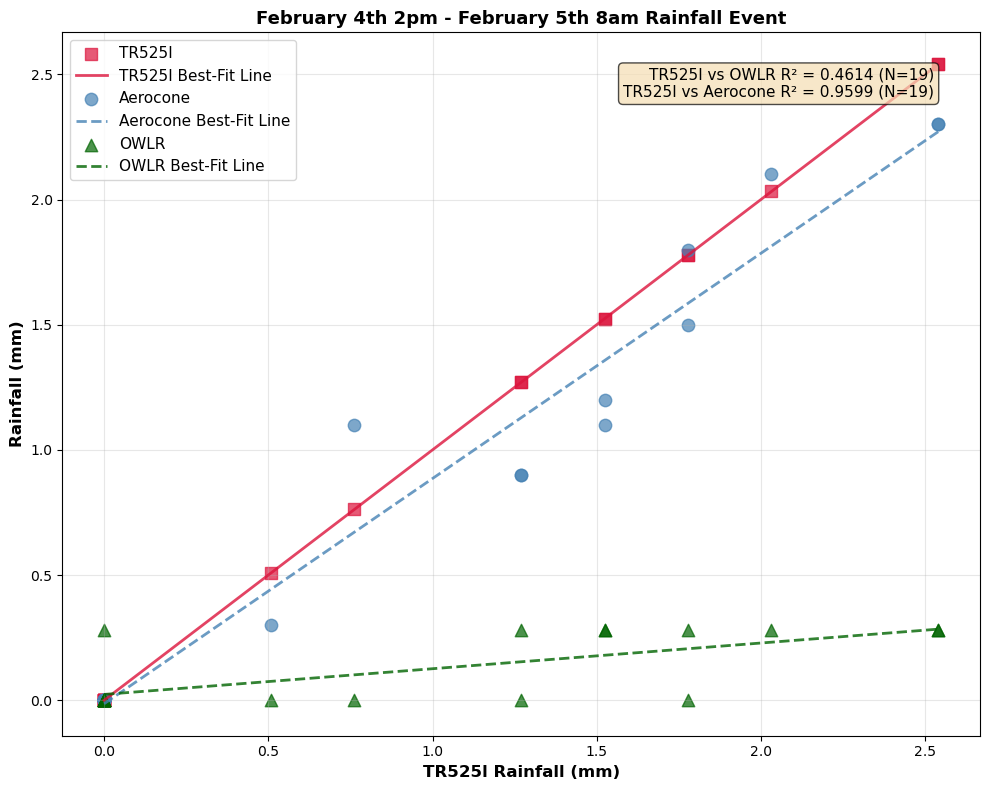


Summary Statistics for February 4th 2pm - February 5th 8am:
CORMP - Min: 0.0000, Max: 2.5400, Mean: 0.9224
Davis - Min: 0.0000, Max: 2.3000, Mean: 0.8158
rainfall_0000 - Min: 0.0000, Max: 0.2800, Mean: 0.1179


In [33]:
# February 4th 2pm to February 5th 8am — TR525l vs Aerocone and OWLR Comparison

print("=" * 70)
print("ANALYSIS 8: February 4th 2pm - February 5th 8am — TR525l vs Aerocone and OWLR")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_feb4_5 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_feb4_5 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_feb4_5 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

feb4_start = pd.to_datetime('2026-02-04 14:00')
feb5_end = pd.to_datetime('2026-02-05 08:00')

cormp_feb4_5 = cormp_feb4_5[(cormp_feb4_5['datetime'] >= feb4_start) & (cormp_feb4_5['datetime'] <= feb5_end)].reset_index(drop=True)
davis_feb4_5 = davis_feb4_5[(davis_feb4_5['datetime'] >= feb4_start) & (davis_feb4_5['datetime'] <= feb5_end)].reset_index(drop=True)
rain0_feb4_5 = rain0_feb4_5[(rain0_feb4_5['datetime'] >= feb4_start) & (rain0_feb4_5['datetime'] <= feb5_end)].reset_index(drop=True)

print(f"\nFebruary 4th 2pm - February 5th 8am Data:")
print(f"  CORMP records: {len(cormp_feb4_5)}")
print(f"  Davis records: {len(davis_feb4_5)}")
print(f"  rainfall_0000 records: {len(rain0_feb4_5)}")

# Round all to nearest HOUR to align hourly data
cormp_feb4_5['datetime'] = cormp_feb4_5['datetime'].dt.floor('h')
davis_feb4_5['datetime'] = davis_feb4_5['datetime'].dt.floor('h')
rain0_feb4_5['datetime'] = rain0_feb4_5['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_feb4_5 = pd.merge(cormp_feb4_5, davis_feb4_5, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_feb4_5 = pd.merge(merged_feb4_5, rain0_feb4_5, on='datetime', how='outer')
merged_feb4_5 = merged_feb4_5.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_feb4_5.shape}")

# Compute R2 values for annotation
r2_cormp_owlr = float('nan')
r2_cormp_davis = float('nan')
n_cormp_owlr = 0
n_cormp_davis = 0
if not merged_feb4_5.empty:
    cormp_owlr = merged_feb4_5[
        merged_feb4_5['rain_mm_cormp'].notna() & merged_feb4_5['rain_mm_rain0'].notna()
    ]
    n_cormp_owlr = len(cormp_owlr)
    if n_cormp_owlr > 0:
        corr_cormp_owlr = cormp_owlr['rain_mm_cormp'].corr(cormp_owlr['rain_mm_rain0'])
        r2_cormp_owlr = corr_cormp_owlr**2

    cormp_davis = merged_feb4_5[
        merged_feb4_5['rain_mm_cormp'].notna() & merged_feb4_5['rain_mm_davis'].notna()
    ]
    n_cormp_davis = len(cormp_davis)
    if n_cormp_davis > 0:
        corr_cormp_davis = cormp_davis['rain_mm_cormp'].corr(cormp_davis['rain_mm_davis'])
        r2_cormp_davis = corr_cormp_davis**2

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_feb4_5.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_feb4_5[merged_feb4_5['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'],
                   s=80, alpha=0.7, color='crimson', label='TR525l', marker='s')
        print(f"  Plotted {len(cormp_data)} TR525l data points")
        x_cormp = cormp_data['rain_mm_cormp']
        y_cormp = cormp_data['rain_mm_cormp']
        slope_cormp, intercept_cormp = np.polyfit(x_cormp, y_cormp, 1)
        x_line_cormp = np.array([x_cormp.min(), x_cormp.max()])
        y_line_cormp = slope_cormp * x_line_cormp + intercept_cormp
        plt.plot(x_line_cormp, y_line_cormp,
                 color='crimson', linewidth=2, alpha=0.8, label='TR525l Best-Fit Line')

    # Plot Davis data and best-fit line
    davis_data = merged_feb4_5[merged_feb4_5['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'],
                   s=80, alpha=0.7, color='steelblue', label='Aerocone', marker='o')
        print(f"  Plotted {len(davis_data)} Aerocone data points")
        davis_fit = merged_feb4_5[
            merged_feb4_5['rain_mm_cormp'].notna() & merged_feb4_5['rain_mm_davis'].notna()
        ]
        if len(davis_fit) >= 2:
            x_fit_davis = davis_fit['rain_mm_cormp']
            y_fit_davis = davis_fit['rain_mm_davis']
            slope_davis, intercept_davis = np.polyfit(x_fit_davis, y_fit_davis, 1)
            x_line_davis = np.array([x_fit_davis.min(), x_fit_davis.max()])
            y_line_davis = slope_davis * x_line_davis + intercept_davis
            plt.plot(x_line_davis, y_line_davis,
                     color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Aerocone Best-Fit Line')

    # Plot rainfall_0000 data and best-fit line
    rain0_data = merged_feb4_5[merged_feb4_5['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'],
                   s=80, alpha=0.7, color='darkgreen', label='OWLR', marker='^')
        print(f"  Plotted {len(rain0_data)} OWLR data points")
        owlr_fit = merged_feb4_5[
            merged_feb4_5['rain_mm_cormp'].notna() & merged_feb4_5['rain_mm_rain0'].notna()
        ]
        if len(owlr_fit) >= 2:
            x_fit_owlr = owlr_fit['rain_mm_cormp']
            y_fit_owlr = owlr_fit['rain_mm_rain0']
            slope_owlr, intercept_owlr = np.polyfit(x_fit_owlr, y_fit_owlr, 1)
            x_line_owlr = np.array([x_fit_owlr.min(), x_fit_owlr.max()])
            y_line_owlr = slope_owlr * x_line_owlr + intercept_owlr
            plt.plot(x_line_owlr, y_line_owlr,
                     color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR Best-Fit Line')

# Add R2 annotation to plot
annotation_lines = []
if pd.notna(r2_cormp_owlr):
    annotation_lines.append(f"TR525l vs OWLR R² = {r2_cormp_owlr:.4f} (N={n_cormp_owlr})")
if pd.notna(r2_cormp_davis):
    annotation_lines.append(f"TR525l vs Aerocone R² = {r2_cormp_davis:.4f} (N={n_cormp_davis})")
if annotation_lines:
    ax = plt.gca()
    ax.text(
        0.95, 0.95,
        "\n".join(annotation_lines),
        transform=ax.transAxes,
        fontsize=11,
        va='top',
        ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    )

plt.xlabel('TR525l Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('February 4th 2pm - February 5th 8am Rainfall Event', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for February 4th 2pm - February 5th 8am:")
print("=" * 70)
if 'rain_mm_cormp' in merged_feb4_5.columns:
    print(f"CORMP - Min: {merged_feb4_5['rain_mm_cormp'].min():.4f}, Max: {merged_feb4_5['rain_mm_cormp'].max():.4f}, Mean: {merged_feb4_5['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_feb4_5.columns:
    print(f"Davis - Min: {merged_feb4_5['rain_mm_davis'].min():.4f}, Max: {merged_feb4_5['rain_mm_davis'].max():.4f}, Mean: {merged_feb4_5['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_feb4_5.columns:
    print(f"rainfall_0000 - Min: {merged_feb4_5['rain_mm_rain0'].min():.4f}, Max: {merged_feb4_5['rain_mm_rain0'].max():.4f}, Mean: {merged_feb4_5['rain_mm_rain0'].mean():.4f}")

ANALYSIS 9: February 15th 12am - February 17th 12am — CORMP vs Davis and rainfall_0000

February 15th 12am - February 17th 12am Data:
  CORMP records: 49
  Davis records: 49
  rainfall_0000 records: 49

Merged dataset shape: (49, 8)

Generating scatter plot...
  Plotted 49 TR525l data points
  Plotted 49 Aerocone data points
  Plotted 49 OWLR data points


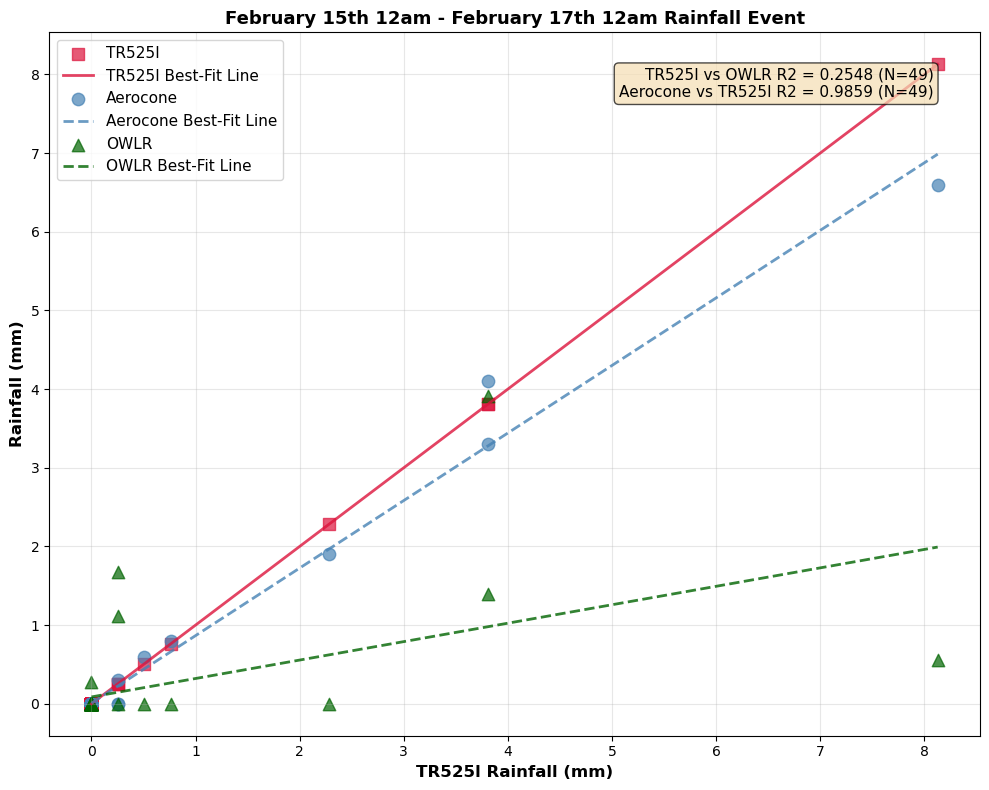


Summary Statistics for February 15th 12am - February 17th 12am:
TR525l - Min: 0.0000, Max: 8.1280, Mean: 0.4095
Aerocone - Min: 0.0000, Max: 6.6000, Mean: 0.3592
OWLR - Min: 0.0000, Max: 3.9100, Mean: 0.1827


In [34]:
# February 15th 12am to February 17th 12am — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 9: February 15th 12am - February 17th 12am — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_feb15_17 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_feb15_17 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_feb15_17 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

feb15_start = pd.to_datetime('2026-02-15 00:00')
feb17_end = pd.to_datetime('2026-02-17 00:00')

cormp_feb15_17 = cormp_feb15_17[(cormp_feb15_17['datetime'] >= feb15_start) & (cormp_feb15_17['datetime'] <= feb17_end)].reset_index(drop=True)
davis_feb15_17 = davis_feb15_17[(davis_feb15_17['datetime'] >= feb15_start) & (davis_feb15_17['datetime'] <= feb17_end)].reset_index(drop=True)
rain0_feb15_17 = rain0_feb15_17[(rain0_feb15_17['datetime'] >= feb15_start) & (rain0_feb15_17['datetime'] <= feb17_end)].reset_index(drop=True)

print(f"\nFebruary 15th 12am - February 17th 12am Data:")
print(f"  CORMP records: {len(cormp_feb15_17)}")
print(f"  Davis records: {len(davis_feb15_17)}")
print(f"  rainfall_0000 records: {len(rain0_feb15_17)}")

# Round all to nearest HOUR to align hourly data
cormp_feb15_17['datetime'] = cormp_feb15_17['datetime'].dt.floor('h')
davis_feb15_17['datetime'] = davis_feb15_17['datetime'].dt.floor('h')
rain0_feb15_17['datetime'] = rain0_feb15_17['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_feb15_17 = pd.merge(cormp_feb15_17, davis_feb15_17, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_feb15_17 = pd.merge(merged_feb15_17, rain0_feb15_17, on='datetime', how='outer')
merged_feb15_17 = merged_feb15_17.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_feb15_17.shape}")

# Compute R2 values for annotations
r2_cr_feb = float('nan')
r2_dc_feb = float('nan')
n_cr = 0
n_dc = 0
if not merged_feb15_17.empty:
    cormp_rain0 = merged_feb15_17[
        merged_feb15_17['rain_mm_cormp'].notna() & merged_feb15_17['rain_mm_rain0'].notna()
    ]
    n_cr = len(cormp_rain0)
    if n_cr > 0:
        corr_cr_feb = cormp_rain0['rain_mm_cormp'].corr(cormp_rain0['rain_mm_rain0'])
        r2_cr_feb = corr_cr_feb**2

    davis_cormp = merged_feb15_17[
        merged_feb15_17['rain_mm_cormp'].notna() & merged_feb15_17['rain_mm_davis'].notna()
    ]
    n_dc = len(davis_cormp)
    if n_dc > 0:
        corr_dc_feb = davis_cormp['rain_mm_cormp'].corr(davis_cormp['rain_mm_davis'])
        r2_dc_feb = corr_dc_feb**2

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_feb15_17.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_feb15_17[merged_feb15_17['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'],
                   s=80, alpha=0.7, color='crimson', label='TR525l', marker='s')
        x_cormp = cormp_data['rain_mm_cormp']
        y_cormp = cormp_data['rain_mm_cormp']
        slope_cormp, intercept_cormp = np.polyfit(x_cormp, y_cormp, 1)
        x_line_cormp = np.array([x_cormp.min(), x_cormp.max()])
        y_line_cormp = slope_cormp * x_line_cormp + intercept_cormp
        plt.plot(x_line_cormp, y_line_cormp,
                 color='crimson', linewidth=2, alpha=0.8, label='TR525l Best-Fit Line')
        print(f"  Plotted {len(cormp_data)} TR525l data points")

    # Plot Davis data and best-fit line
    davis_data = merged_feb15_17[merged_feb15_17['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'],
                   s=80, alpha=0.7, color='steelblue', label='Aerocone', marker='o')
        print(f"  Plotted {len(davis_data)} Aerocone data points")
        davis_fit = merged_feb15_17[
            merged_feb15_17['rain_mm_cormp'].notna() & merged_feb15_17['rain_mm_davis'].notna()
        ]
        if len(davis_fit) >= 2:
            x_fit_davis = davis_fit['rain_mm_cormp']
            y_fit_davis = davis_fit['rain_mm_davis']
            slope_davis, intercept_davis = np.polyfit(x_fit_davis, y_fit_davis, 1)
            x_line_davis = np.array([x_fit_davis.min(), x_fit_davis.max()])
            y_line_davis = slope_davis * x_line_davis + intercept_davis
            plt.plot(x_line_davis, y_line_davis,
                     color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Aerocone Best-Fit Line')

    # Plot OWLR data and best-fit line
    rain0_data = merged_feb15_17[merged_feb15_17['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'],
                   s=80, alpha=0.7, color='darkgreen', label='OWLR', marker='^')
        print(f"  Plotted {len(rain0_data)} OWLR data points")
        rain0_fit = merged_feb15_17[
            merged_feb15_17['rain_mm_cormp'].notna() & merged_feb15_17['rain_mm_rain0'].notna()
        ]
        if len(rain0_fit) >= 2:
            x_fit_rain0 = rain0_fit['rain_mm_cormp']
            y_fit_rain0 = rain0_fit['rain_mm_rain0']
            slope_rain0, intercept_rain0 = np.polyfit(x_fit_rain0, y_fit_rain0, 1)
            x_line_rain0 = np.array([x_fit_rain0.min(), x_fit_rain0.max()])
            y_line_rain0 = slope_rain0 * x_line_rain0 + intercept_rain0
            plt.plot(x_line_rain0, y_line_rain0,
                     color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR Best-Fit Line')

    # Annotate R2 values (upper right)
    annotation_lines = []
    if pd.notna(r2_cr_feb):
        annotation_lines.append(f"TR525l vs OWLR R2 = {r2_cr_feb:.4f} (N={n_cr})")
    if pd.notna(r2_dc_feb):
        annotation_lines.append(f"Aerocone vs TR525l R2 = {r2_dc_feb:.4f} (N={n_dc})")
    if annotation_lines:
        ax = plt.gca()
        ax.text(0.95, 0.95, "\n".join(annotation_lines), transform=ax.transAxes, fontsize=11, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.xlabel('TR525l Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('February 15th 12am - February 17th 12am Rainfall Event', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for February 15th 12am - February 17th 12am:")
print("=" * 70)
if 'rain_mm_cormp' in merged_feb15_17.columns:
    print(f"TR525l - Min: {merged_feb15_17['rain_mm_cormp'].min():.4f}, Max: {merged_feb15_17['rain_mm_cormp'].max():.4f}, Mean: {merged_feb15_17['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_feb15_17.columns:
    print(f"Aerocone - Min: {merged_feb15_17['rain_mm_davis'].min():.4f}, Max: {merged_feb15_17['rain_mm_davis'].max():.4f}, Mean: {merged_feb15_17['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_feb15_17.columns:
    print(f"OWLR - Min: {merged_feb15_17['rain_mm_rain0'].min():.4f}, Max: {merged_feb15_17['rain_mm_rain0'].max():.4f}, Mean: {merged_feb15_17['rain_mm_rain0'].mean():.4f}")

ANALYSIS 10: March 15th 8pm - March 17th 8am — CORMP vs Davis and rainfall_0000

March 15th 8pm - March 17th 8am Data:
  CORMP records: 37
  Davis records: 37
  rainfall_0000 records: 74

Merged dataset shape: (74, 8)

Generating scatter plot...
  Plotted 74 TR525l data points
  Plotted 74 Aerocone data points
  Plotted 74 OWLR data points


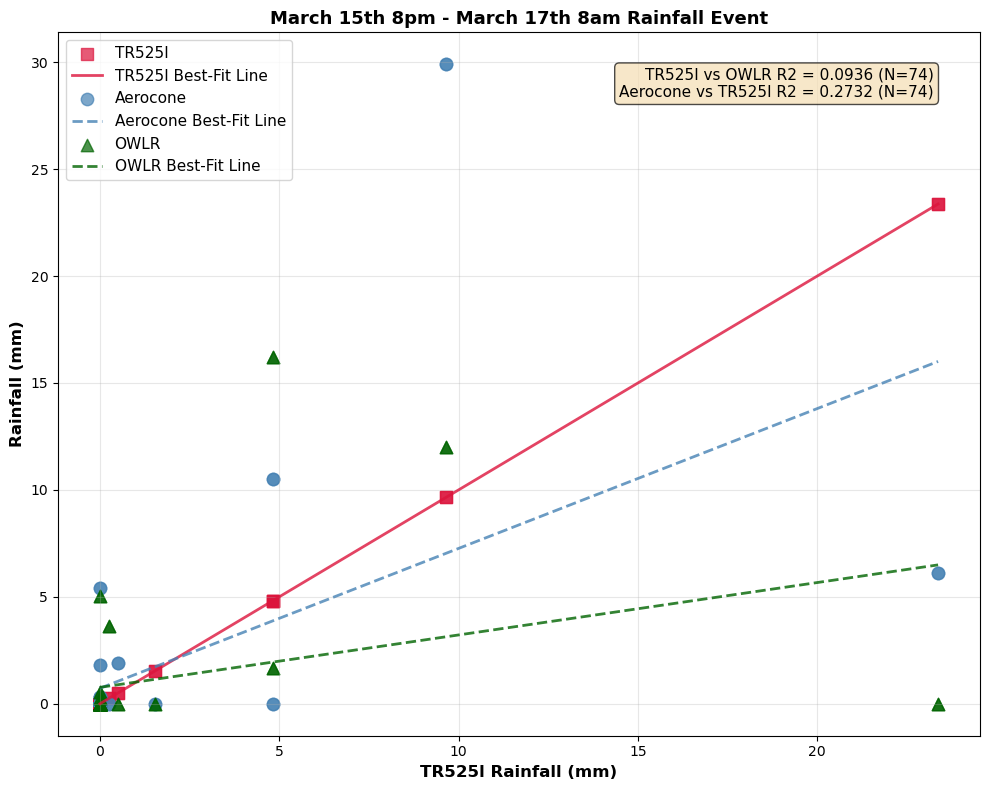


Summary Statistics for March 15th 8pm - March 17th 8am:
CORMP - Min: 0.0000, Max: 23.3680, Mean: 1.2151
Davis - Min: 0.0000, Max: 29.9000, Mean: 1.5189
rainfall_0000 - Min: 0.0000, Max: 16.2100, Mean: 1.0649


In [23]:
# March 15th 8pm to March 17th 8am — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 10: March 15th 8pm - March 17th 8am — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_mar15_17 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_mar15_17 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_mar15_17 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

mar15_start = pd.to_datetime('2026-03-15 20:00')
mar17_end = pd.to_datetime('2026-03-17 08:00')

cormp_mar15_17 = cormp_mar15_17[(cormp_mar15_17['datetime'] >= mar15_start) & (cormp_mar15_17['datetime'] <= mar17_end)].reset_index(drop=True)
davis_mar15_17 = davis_mar15_17[(davis_mar15_17['datetime'] >= mar15_start) & (davis_mar15_17['datetime'] <= mar17_end)].reset_index(drop=True)
rain0_mar15_17 = rain0_mar15_17[(rain0_mar15_17['datetime'] >= mar15_start) & (rain0_mar15_17['datetime'] <= mar17_end)].reset_index(drop=True)

print(f"\nMarch 15th 8pm - March 17th 8am Data:")
print(f"  CORMP records: {len(cormp_mar15_17)}")
print(f"  Davis records: {len(davis_mar15_17)}")
print(f"  rainfall_0000 records: {len(rain0_mar15_17)}")

# Round all to nearest HOUR to align hourly data
cormp_mar15_17['datetime'] = cormp_mar15_17['datetime'].dt.floor('h')
davis_mar15_17['datetime'] = davis_mar15_17['datetime'].dt.floor('h')
rain0_mar15_17['datetime'] = rain0_mar15_17['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_mar15_17 = pd.merge(cormp_mar15_17, davis_mar15_17, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_mar15_17 = pd.merge(merged_mar15_17, rain0_mar15_17, on='datetime', how='outer')
merged_mar15_17 = merged_mar15_17.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_mar15_17.shape}")

# Compute R2 values for annotations
r2_cr_mar = float('nan')
r2_dc_mar = float('nan')
n_cr_mar = 0
n_dc_mar = 0
if not merged_mar15_17.empty:
    cormp_rain0_mar = merged_mar15_17[
        merged_mar15_17['rain_mm_cormp'].notna() & merged_mar15_17['rain_mm_rain0'].notna()
    ]
    n_cr_mar = len(cormp_rain0_mar)
    if n_cr_mar > 0:
        corr_cr_mar = cormp_rain0_mar['rain_mm_cormp'].corr(cormp_rain0_mar['rain_mm_rain0'])
        r2_cr_mar = corr_cr_mar**2

    davis_cormp_mar = merged_mar15_17[
        merged_mar15_17['rain_mm_cormp'].notna() & merged_mar15_17['rain_mm_davis'].notna()
    ]
    n_dc_mar = len(davis_cormp_mar)
    if n_dc_mar > 0:
        corr_dc_mar = davis_cormp_mar['rain_mm_cormp'].corr(davis_cormp_mar['rain_mm_davis'])
        r2_dc_mar = corr_dc_mar**2

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_mar15_17.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_mar15_17[merged_mar15_17['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'],
                   s=80, alpha=0.7, color='crimson', label='TR525l', marker='s')
        x_cormp = cormp_data['rain_mm_cormp']
        y_cormp = cormp_data['rain_mm_cormp']
        slope_cormp, intercept_cormp = np.polyfit(x_cormp, y_cormp, 1)
        x_line_cormp = np.array([x_cormp.min(), x_cormp.max()])
        y_line_cormp = slope_cormp * x_line_cormp + intercept_cormp
        plt.plot(x_line_cormp, y_line_cormp,
                 color='crimson', linewidth=2, alpha=0.8, label='TR525l Best-Fit Line')
        print(f"  Plotted {len(cormp_data)} TR525l data points")

    # Plot Davis data and best-fit line
    davis_data = merged_mar15_17[merged_mar15_17['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'],
                   s=80, alpha=0.7, color='steelblue', label='Aerocone', marker='o')
        print(f"  Plotted {len(davis_data)} Aerocone data points")
        davis_fit = merged_mar15_17[
            merged_mar15_17['rain_mm_cormp'].notna() & merged_mar15_17['rain_mm_davis'].notna()
        ]
        if len(davis_fit) >= 2:
            x_fit_davis = davis_fit['rain_mm_cormp']
            y_fit_davis = davis_fit['rain_mm_davis']
            slope_davis, intercept_davis = np.polyfit(x_fit_davis, y_fit_davis, 1)
            x_line_davis = np.array([x_fit_davis.min(), x_fit_davis.max()])
            y_line_davis = slope_davis * x_line_davis + intercept_davis
            plt.plot(x_line_davis, y_line_davis,
                     color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Aerocone Best-Fit Line')

    # Plot rainfall_0000 data and best-fit line
    rain0_data = merged_mar15_17[merged_mar15_17['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'],
                   s=80, alpha=0.7, color='darkgreen', label='OWLR', marker='^')
        print(f"  Plotted {len(rain0_data)} OWLR data points")
        owlr_fit = merged_mar15_17[
            merged_mar15_17['rain_mm_cormp'].notna() & merged_mar15_17['rain_mm_rain0'].notna()
        ]
        if len(owlr_fit) >= 2:
            x_fit_owlr = owlr_fit['rain_mm_cormp']
            y_fit_owlr = owlr_fit['rain_mm_rain0']
            slope_owlr, intercept_owlr = np.polyfit(x_fit_owlr, y_fit_owlr, 1)
            x_line_owlr = np.array([x_fit_owlr.min(), x_fit_owlr.max()])
            y_line_owlr = slope_owlr * x_line_owlr + intercept_owlr
            plt.plot(x_line_owlr, y_line_owlr,
                     color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR Best-Fit Line')

    # Annotate R2 values (upper right)
    annotation_lines = []
    if pd.notna(r2_cr_mar):
        annotation_lines.append(f"TR525l vs OWLR R2 = {r2_cr_mar:.4f} (N={n_cr_mar})")
    if pd.notna(r2_dc_mar):
        annotation_lines.append(f"Aerocone vs TR525l R2 = {r2_dc_mar:.4f} (N={n_dc_mar})")
    if annotation_lines:
        ax = plt.gca()
        ax.text(0.95, 0.95, "\n".join(annotation_lines), transform=ax.transAxes, fontsize=11, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.xlabel('TR525l Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('March 15th 8pm - March 17th 8am Rainfall Event', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for March 15th 8pm - March 17th 8am:")
print("=" * 70)
if 'rain_mm_cormp' in merged_mar15_17.columns:
    print(f"CORMP - Min: {merged_mar15_17['rain_mm_cormp'].min():.4f}, Max: {merged_mar15_17['rain_mm_cormp'].max():.4f}, Mean: {merged_mar15_17['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_mar15_17.columns:
    print(f"Davis - Min: {merged_mar15_17['rain_mm_davis'].min():.4f}, Max: {merged_mar15_17['rain_mm_davis'].max():.4f}, Mean: {merged_mar15_17['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_mar15_17.columns:
    print(f"rainfall_0000 - Min: {merged_mar15_17['rain_mm_rain0'].min():.4f}, Max: {merged_mar15_17['rain_mm_rain0'].max():.4f}, Mean: {merged_mar15_17['rain_mm_rain0'].mean():.4f}")